# Bushfire – Synoptic Weather Type (SWT) Analysis

Continuing the compound-events direction. This notebook:

1. **Extracts** `bushfire_events_geo.csv` from the National Bushfire Historical Extents FGDB — polygon-level, with centroids (computed in EPSG:3577 Albers, reported as lat/lon), both ignition & extinguish dates, a `is_jan1` placeholder flag, and a clean state code.
2. Builds the **simultaneity (compound) analysis**: do ≥2 states burn at once more often under particular continental SWTs?

**Interval note:** extinguish dates are present for only ~37% of national bushfires and ~31% of those are corrupt (extinguish ≤ ignition). So burn intervals use a **size-scaled window** (fallback), with real dates used only as a cross-check where valid.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np

# --- paths ---
DATA_DIR  = "/Users/smar0095/Fires_SWTs"
GDB       = f"{DATA_DIR}/Bushfire Extents - Historical (2025).gdb"
SWT_CSV   = f"{DATA_DIR}/SWT_climatology_v20260129.csv"
GEO_CSV   = f"{DATA_DIR}/bushfire_events_geo.csv"   # output of step 1

LAYERS = ["National_Historical_Bushfire_Extents_v4",
          "NT_Historical_Bushfire_Extents_v1"]

ALBERS = 3577   # Australian Albers (metres) — correct CRS for centroids
LATLON = 4326

print("geopandas", gpd.__version__, "| pandas", pd.__version__)

geopandas 1.1.3 | pandas 2.3.3


## Inspect: native CRS and raw state values

Quick look before extraction, so the centroid reprojection and state normalisation are built correctly.

In [2]:
# native CRS (read a few rows with geometry)
_g = gpd.read_file(GDB, layer=LAYERS[0], rows=5)
print("native CRS:", _g.crs)

# raw state values across both layers (attrs only, fast)
for lyr in LAYERS:
    _df = gpd.read_file(GDB, layer=lyr, ignore_geometry=True, columns=["fire_type", "state"])
    _bf = _df[_df["fire_type"] == "Bushfire"]
    print(f"\n-- {lyr}  (bushfires={len(_bf)}) --")
    print(_bf["state"].value_counts(dropna=False).to_string())

native CRS: EPSG:4283



-- National_Historical_Bushfire_Extents_v4  (bushfires=85336) --
state
NSW (New South Wales)                 43140
WA (Western Australia)                12839
VIC (Victoria)                        10494
QLD (Queensland)                       6865
TAS (Tasmania)                         5487
SA (South Australia)                   5223
ACT (Australian Capital Territory)     1288

-- NT_Historical_Bushfire_Extents_v1  (bushfires=612) --
state
NT    609
WA      3


## Step 1 — Extract `bushfire_events_geo.csv`

Polygon-level. Centroids computed in EPSG:3577 (Albers, metres) then reported as lat/lon (EPSG:4326). Dates parsed with `errors="coerce"` (handles the out-of-range 0200 / 2525 placeholders); tz dropped. `is_jan1` flags the year-known / day-unknown placeholders. State normalised to a clean code.

In [3]:
import os
if os.path.exists(GEO_CSV):  # one-time GDB extraction; skip the fragile read on re-bakes
    out = pd.read_csv(GEO_CSV, parse_dates=['ignition_date', 'extinguish_date'])
    print(f'Step 1: using existing {GEO_CSV} ({len(out):,} rows) - skipped GDB re-extraction')
else:
    USE_COLS = ["fire_id", "fire_name", "ignition_date", "extinguish_date",
                "area_ha", "state", "fire_type"]

    def parse_dt(s):
        """Parse to naive (tz-dropped) datetime; out-of-range placeholders -> NaT."""
        dt = pd.to_datetime(s, errors="coerce", utc=True)
        return dt.dt.tz_localize(None)

    parts = []
    for lyr in LAYERS:
        g = gpd.read_file(GDB, layer=lyr, columns=USE_COLS, on_invalid="warn")  # AUDIT: tolerate bad rings
        g = g[g["fire_type"] == "Bushfire"].copy()
        # centroids: project to Albers (metres) -> centroid -> back to lat/lon
        cent = g.geometry.to_crs(ALBERS).centroid.to_crs(LATLON)
        g["lon"] = cent.x.values
        g["lat"] = cent.y.values
        g["layer"] = lyr
        parts.append(pd.DataFrame(g.drop(columns="geometry")))

    polys = pd.concat(parts, ignore_index=True)

    # dates
    polys["ignition_date"]   = parse_dt(polys["ignition_date"])
    polys["extinguish_date"] = parse_dt(polys["extinguish_date"])

    # placeholder flag (Jan-1 = year-known/day-unknown) and drop no-ignition rows
    polys = polys[polys["ignition_date"].notna()].copy()
    polys["is_jan1"] = (polys["ignition_date"].dt.month == 1) & (polys["ignition_date"].dt.day == 1)

    # clean state code (leading 2-3 letter code from "NSW (New South Wales)" or "NSW")
    polys["state"] = polys["state"].str.extract(r"^\s*([A-Za-z]{2,3})")[0].str.upper()

    out = polys[["fire_id", "fire_name", "ignition_date", "extinguish_date",
                 "area_ha", "state", "lat", "lon", "is_jan1", "layer"]]
    out.to_csv(GEO_CSV, index=False)

    # report the post-1899-sentinel range: 1899-12-30 is the OLE/Excel epoch null-date,
    # not a real fire, so exclude it (and Jan-1 placeholders) from the "real" range print
    real = out.loc[~out["is_jan1"] & (out["ignition_date"] > "1900-01-01"), "ignition_date"]
    print(f"wrote {GEO_CSV}: {len(out):,} polygon rows")
    print(f"  is_jan1 placeholders: {out['is_jan1'].sum():,} ({100*out['is_jan1'].mean():.0f}%)")
    print(f"  date range (real, non-Jan1, post-1900): {real.min().date()} -> {real.max().date()}")
    print("  state counts:\n" + out["state"].value_counts(dropna=False).to_string())
    print("  centroid sanity (should be within AU): "
          f"lon {out['lon'].min():.1f}..{out['lon'].max():.1f}, "
          f"lat {out['lat'].min():.1f}..{out['lat'].max():.1f}")

Step 1: using existing /Users/smar0095/Fires_SWTs/bushfire_events_geo.csv (85,793 rows) - skipped GDB re-extraction


## Step 2 — Simultaneity (compound) analysis

**Question:** does a single continental SWT make *multiple regions burn at once*, beyond what season alone explains?

**Unit = day.** Each fire footprint is given a burn interval `[ignition, ignition + duration)`. A *state is burning* on a day if any of its footprints is active. A day is **multi-state** if ≥ `MIN_STATES` distinct states are burning. ACT is folded into NSW (geographically enclosed) to avoid spurious co-occurrence.

**Burn duration (size-scaled fallback).** Real extinguish dates are too sparse/corrupt to use directly, so duration is the **median real duration of its area class** (computed on the clean-interval subset, `0 < dur ≤ 365`), so larger fires get longer windows. Capped at `CAP_DAYS`.

**Metrics per SWT / regime:**
- `p_multi` = P(multi-state day | SWT)
- `sync` = P(multi-state | ≥1 state burning, SWT) — isolates *spatial synchronisation* from raw fire propensity
- `RR_multi` = frac(multi-state days under SWT) / frac(seasonally-matched background days under SWT), with 1000-draw bootstrap CIs (same seasonal control as the event-level RR), FDR-corrected at the SWT level.

In [4]:
# ---- config ----
MIN_AREA_HA = 1000     # large-fire threshold (small grassfires would make co-occurrence trivial)
MIN_STATES  = 2        # a day is "multi-state" if >= this many states burning
CAP_DAYS    = 60       # generous cap; bin medians drive the actual durations
N_BOOT      = 1000
STATE_FOLD  = {"ACT": "NSW"}   # ACT geographically enclosed by NSW; avoids spurious co-occurrence
# SWT regime families; longest/specific prefixes first so matching is unambiguous
REGIME_PREFIXES = ["WCT", "COL", "WH", "CH", "EH", "TH", "FH", "AM"]

def to_regime(s):
    if isinstance(s, str):
        for p in REGIME_PREFIXES:
            if s.startswith(p):
                return p
    return "Other"

# ---- load SWT climatology (one SWT per calendar day) ----
swt = pd.read_csv(SWT_CSV, parse_dates=["time"])
swt["day"]    = swt["time"].dt.normalize()
swt["month"]  = swt["time"].dt.month
swt["regime"] = swt["assigned_SWT"].apply(to_regime)
# AUDIT FIX (period-matching): fire DANGER (FFDI) exists only 1979-2023, so restrict the WHOLE
# analysis to the FFDI overlap -> fire & danger RR / pairs / conversion all share one period.
_ffd = pd.to_datetime(pd.read_csv(f"{DATA_DIR}/ffdi_state_daily.csv", usecols=["date"])["date"])
ANALYSIS_LO, ANALYSIS_HI = max(swt["day"].min(), _ffd.min()), min(swt["day"].max(), _ffd.max())
swt = swt[(swt["day"] >= ANALYSIS_LO) & (swt["day"] <= ANALYSIS_HI)].reset_index(drop=True)
print(f"ANALYSIS PERIOD (FFDI overlap): {ANALYSIS_LO.date()} -> {ANALYSIS_HI.date()}")
swt_min, swt_max = swt["day"].min(), swt["day"].max()
print(f"SWT climatology: {swt_min.date()} -> {swt_max.date()}  ({len(swt):,} days)")

# ---- load fires ----
df = pd.read_csv(GEO_CSV, parse_dates=["ignition_date", "extinguish_date"])
df["state"] = df["state"].replace(STATE_FOLD)

# ---- size-scaled duration: MEDIAN real duration per area class (robust to outliers) ----
AREA_BINS   = [0, 100, 1_000, 5_000, 20_000, 100_000, np.inf]
AREA_LABELS = ["<100", "100-1k", "1k-5k", "5k-20k", "20k-100k", ">100k"]
df["abin"]  = pd.cut(df["area_ha"], bins=AREA_BINS, labels=AREA_LABELS)

dur_real = (df["extinguish_date"] - df["ignition_date"]).dt.days
clean    = df["extinguish_date"].notna() & (dur_real > 0) & (dur_real <= 365) & (df["area_ha"] > 0)
g_dur    = dur_real[clean].groupby(df.loc[clean, "abin"], observed=True)
bin_med  = g_dur.median()
bin_n    = g_dur.size()

# single source of truth for the size->window map (clip/round applied once)
dur_map = {lab: int(np.clip(round(bin_med[lab]), 1, CAP_DAYS)) for lab in bin_med.index}

print(f"\nsize-scaled duration (median real days per area class, n_clean={clean.sum():,}):")
for lab in AREA_LABELS:
    if lab in dur_map:
        print(f"   {lab:>9} ha -> {dur_map[lab]:>2} days   (n={bin_n[lab]:,})")

# apply to all real-dated large fires in window
large = df[(~df["is_jan1"]) & (df["area_ha"] >= MIN_AREA_HA) &
           (df["ignition_date"] >= swt_min) & (df["ignition_date"] <= swt_max)].copy()
large["dur"] = large["abin"].map(dur_map).astype(int)
print(f"\nlarge-fire footprints (>= {MIN_AREA_HA} ha, real date, in window): {len(large):,}")
print(f"   modelled duration: median {large['dur'].median():.0f}, mean {large['dur'].mean():.1f} days")

ANALYSIS PERIOD (FFDI overlap): 1979-01-01 -> 2023-12-31
SWT climatology: 1979-01-01 -> 2023-12-31  (16,436 days)



size-scaled duration (median real days per area class, n_clean=19,631):
        <100 ha ->  3 days   (n=12,237)
      100-1k ha ->  7 days   (n=4,974)
       1k-5k ha -> 13 days   (n=1,592)
      5k-20k ha -> 17 days   (n=549)
    20k-100k ha -> 25 days   (n=225)
       >100k ha -> 34 days   (n=54)

large-fire footprints (>= 1000 ha, real date, in window): 5,931
   modelled duration: median 13, mean 16.3 days


In [5]:
def build_daily(fires, min_states=MIN_STATES):
    """Expand each fire to its active (day, state) pairs, then return the full
    daily frame over the SWT window (every calendar day, 0 states if no fire)."""
    dur = fires["dur"].values
    ig  = fires["ignition_date"].values.astype("datetime64[D]")
    st  = fires["state"].values
    offs = np.concatenate([np.arange(d) for d in dur]).astype("timedelta64[D]")
    day_arr   = np.repeat(ig, dur) + offs
    state_arr = np.repeat(st, dur)

    state_days = pd.DataFrame({"day": day_arr, "state": state_arr}).drop_duplicates()
    per_day = state_days.groupby("day")["state"].nunique().rename("n_states")

    d = swt[["day", "month", "assigned_SWT", "regime"]].copy()
    d = d.merge(per_day, on="day", how="left")
    d["n_states"]  = d["n_states"].fillna(0).astype(int)
    d["fire_day"]  = d["n_states"] >= 1
    d["multi_day"] = d["n_states"] >= min_states
    return d

daily = build_daily(large)

n_days  = len(daily)
n_fire  = daily["fire_day"].sum()
n_multi = daily["multi_day"].sum()
print(f"days total: {n_days:,}")
print(f"  >=1 state burning: {n_fire:,} ({100*n_fire/n_days:.1f}%)")
print(f"  >={MIN_STATES} states burning (multi): {n_multi:,} ({100*n_multi/n_days:.1f}%)")
print(f"  multi | fire-day: {100*n_multi/n_fire:.1f}%")
print("\n  distribution of #states burning on fire-days:")
print(daily.loc[daily['fire_day'], 'n_states'].value_counts().sort_index().to_string())

days total: 16,436
  >=1 state burning: 10,770 (65.5%)
  >=2 states burning (multi): 6,389 (38.9%)
  multi | fire-day: 59.3%

  distribution of #states burning on fire-days:
n_states
1    4381
2    3098
3    1895
4     838
5     387
6     171


In [6]:
from statsmodels.stats.multitest import multipletests

def simultaneity_rr(level_col, daily_df=None, fdr=False, seed=0, n_boot=N_BOOT):
    """RR that multi-state days fall under each level (SWT or regime),
    vs a seasonally-matched background of all days. Vectorised bootstrap CIs + optional FDR."""
    d = daily if daily_df is None else daily_df
    # integer-code the level so we can use bincount
    codes, items = pd.factorize(d[level_col], sort=True)
    K = len(items)
    month = d["month"].values
    multi_mask = d["multi_day"].values

    multi_codes = codes[multi_mask]
    multi_frac  = np.bincount(multi_codes, minlength=K) / multi_mask.sum()

    # descriptive rates (one grouped pass)
    desc = d.groupby(level_col, observed=True).agg(
        n_days=("multi_day", "size"),
        n_fire=("fire_day", "sum"),
        n_multi=("multi_day", "sum"),
    ).reindex(items)
    desc["p_multi"] = desc["n_multi"] / desc["n_days"]
    desc["sync"]    = desc["n_multi"] / desc["n_fire"].replace(0, np.nan)

    # seasonally-matched bootstrap: per-month resample of ALL days, vectorised
    rng = np.random.default_rng(seed)
    month_idx = {m: np.where(month == m)[0] for m in np.unique(month)}
    multi_month_counts = pd.Series(month[multi_mask]).value_counts().to_dict()

    boot = np.empty((n_boot, K))
    for i in range(n_boot):
        parts = [codes[rng.choice(month_idx[m], size=n, replace=True)]
                 for m, n in multi_month_counts.items()]
        sampled = np.concatenate(parts)
        bg = np.bincount(sampled, minlength=K) / sampled.size
        with np.errstate(divide="ignore", invalid="ignore"):
            boot[i] = np.where(bg > 0, multi_frac / bg, np.nan)

    rr_mean = np.nanmean(boot, axis=0)
    ci_lo   = np.nanpercentile(boot, 2.5, axis=0)
    ci_hi   = np.nanpercentile(boot, 97.5, axis=0)
    # two-sided bootstrap p: fraction of draws on the null side of 1 (vectorised over K)
    frac  = np.where(rr_mean > 1, np.nanmean(boot <= 1, axis=0), np.nanmean(boot >= 1, axis=0))
    pvals = np.minimum(2 * frac, 1.0)

    res = desc.reset_index().rename(columns={"index": level_col})
    res["RR_mean"], res["CI_low"], res["CI_high"], res["pval"] = rr_mean, ci_lo, ci_hi, pvals
    if fdr:
        p = np.clip(res["pval"].values, 1e-4, 1.0)
        res["sig_fdr"], res["q"], _, _ = multipletests(p, alpha=0.05, method="fdr_bh")
    return res.sort_values("RR_mean", ascending=False)

reg = simultaneity_rr("regime")
print("=== REGIME level: RR of >=%d-state (multi) fire days ===" % MIN_STATES)
print(reg[["regime", "n_multi", "p_multi", "sync", "RR_mean", "CI_low", "CI_high"]]
      .round(3).to_string(index=False))

=== REGIME level: RR of >=2-state (multi) fire days ===
regime  n_multi  p_multi  sync  RR_mean  CI_low  CI_high
    TH      751    0.368 0.557    1.055   0.988    1.129
    WH      849    0.376 0.587    1.039   0.975    1.106
    FH      560    0.348 0.555    1.031   0.956    1.116
    AM     1784    0.561 0.691    1.011   0.980    1.040
    CH      442    0.328 0.568    1.003   0.917    1.094
    EH      889    0.320 0.530    0.976   0.924    1.035
   COL      831    0.347 0.582    0.961   0.901    1.022
   WCT      283    0.341 0.567    0.860   0.780    0.953


In [7]:
swt_res = simultaneity_rr("assigned_SWT", fdr=True)
print("=== SWT level: RR of >=%d-state (multi) fire days (FDR-corrected) ===" % MIN_STATES)
show = swt_res[["assigned_SWT", "n_multi", "p_multi", "sync", "RR_mean", "CI_low", "CI_high", "sig_fdr"]]
print(show.round(3).to_string(index=False))

def fmt_swts(res, mask):
    return ", ".join(f"{r.assigned_SWT} ({r.RR_mean:.2f})"
                     for r in res[mask].itertuples())

print("\nElevated & survive FDR:",  fmt_swts(swt_res, (swt_res.RR_mean > 1) & swt_res.sig_fdr))
print("Suppressed & survive FDR:", fmt_swts(swt_res, (swt_res.RR_mean < 1) & swt_res.sig_fdr))

=== SWT level: RR of >=2-state (multi) fire days (FDR-corrected) ===
assigned_SWT  n_multi  p_multi  sync  RR_mean  CI_low  CI_high  sig_fdr
        WH-A      323    0.433 0.636    1.174   1.052    1.313     True
        TH-C      280    0.426 0.621    1.155   1.026    1.308    False
        FH-B      233    0.402 0.572    1.143   1.009    1.309    False
        EH-E      191    0.325 0.558    1.078   0.945    1.248    False
        CH-A      191    0.288 0.546    1.076   0.927    1.248    False
        AM-E      414    0.601 0.729    1.060   0.967    1.156    False
        TH-A      286    0.368 0.558    1.033   0.932    1.163    False
        AM-B      406    0.562 0.693    1.030   0.944    1.128    False
        WH-C      196    0.381 0.582    1.018   0.883    1.174    False
        FH-C      156    0.299 0.540    1.015   0.876    1.200    False
       COL-E      169    0.350 0.589    1.015   0.862    1.182    False
       COL-F      131    0.327 0.567    1.008   0.851    1.191    F

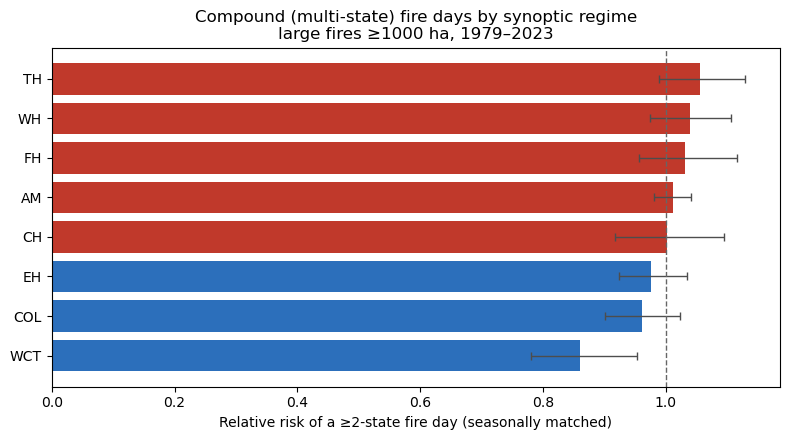

saved multistate_regime_RR.png


In [8]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(8, 4.5))
d = reg.sort_values("RR_mean")
colors = ["#c0392b" if r > 1 else "#2c6fbb" for r in d["RR_mean"]]
ax.barh(d["regime"], d["RR_mean"], color=colors,
        xerr=[d["RR_mean"]-d["CI_low"], d["CI_high"]-d["RR_mean"]],
        error_kw=dict(ecolor="0.3", lw=1, capsize=3))
ax.axvline(1, ls="--", color="0.4", lw=1)
ax.set_xlabel(f"Relative risk of a ≥{MIN_STATES}-state fire day (seasonally matched)")
ax.set_title(f"Compound (multi-state) fire days by synoptic regime\nlarge fires ≥{MIN_AREA_HA} ha, {swt_min.year}–{swt_max.year}")
fig.tight_layout()
fig.savefig(f"{DATA_DIR}/multistate_regime_RR.png", dpi=150)
plt.show()
print("saved multistate_regime_RR.png")

## Step 3 — Sensitivity checks

Two robustness checks for the headline result (FH-B / WH-A / TH-C elevated, WCT-B suppressed):

- **A. Jan-1 inclusion** — the baseline drops *all* Jan-1 ignitions as placeholders, which also deletes genuine early-season fire days (a peak fire-risk window). Re-run keeping them.
- **B. Block bootstrap** — the iid per-day bootstrap ignores temporal autocorrelation from multi-day burn windows and SWT persistence, so it likely overstates significance. Re-run with a circular block bootstrap.

In [9]:
# --- Sensitivity A: keep genuine Jan-1 fires (don't treat all Jan-1 as placeholder) ---
# Early January is peak fire season (e.g. Black Summer, burning 1 Jan 2020). The baseline
# drops EVERY Jan-1 ignition as a year-known/day-unknown placeholder, which can delete real
# multi-state compound days. Here we keep Jan-1 fires and re-run the SWT-level RR.
large_j1 = df[(df["area_ha"] >= MIN_AREA_HA) &
              (df["ignition_date"] >= swt_min) & (df["ignition_date"] <= swt_max)].copy()
large_j1["dur"] = large_j1["abin"].map(dur_map).astype(int)
daily_j1 = build_daily(large_j1)

n_multi_j1 = daily_j1["multi_day"].sum()
print(f"large fires incl. Jan-1: {len(large_j1):,}  (+{len(large_j1)-len(large):,} vs baseline {len(large):,})")
print(f"multi-state days: {n_multi_j1:,} ({100*n_multi_j1/len(daily_j1):.1f}%)  "
      f"vs baseline {n_multi:,} ({100*n_multi/n_days:.1f}%)")

swt_j1 = simultaneity_rr("assigned_SWT", daily_df=daily_j1, fdr=True)

cmp = (swt_res[["assigned_SWT", "RR_mean", "sig_fdr"]]
       .merge(swt_j1[["assigned_SWT", "RR_mean", "sig_fdr"]],
              on="assigned_SWT", suffixes=("_base", "_j1")))
cmp["dRR"] = cmp["RR_mean_j1"] - cmp["RR_mean_base"]
mask = cmp["sig_fdr_base"] | cmp["sig_fdr_j1"]
print("\nSWTs significant in either run (baseline vs incl-Jan-1):")
print(cmp[mask].sort_values("RR_mean_j1", ascending=False).round(3).to_string(index=False))
print("\nElevated & survive FDR (incl Jan-1):",
      fmt_swts(swt_j1, (swt_j1.RR_mean > 1) & swt_j1.sig_fdr))

large fires incl. Jan-1: 7,213  (+1,282 vs baseline 5,931)
multi-state days: 6,647 (40.4%)  vs baseline 6,389 (38.9%)

SWTs significant in either run (baseline vs incl-Jan-1):
assigned_SWT  RR_mean_base  sig_fdr_base  RR_mean_j1  sig_fdr_j1    dRR
        WH-A         1.174          True       1.158       False -0.016

Elevated & survive FDR (incl Jan-1): 


### Sensitivity B — block bootstrap (autocorrelation-robust)

The iid per-day bootstrap above treats the 26,937 days as exchangeable within month. But multi-day burn windows (13–34 d) and SWT persistence make consecutive days strongly autocorrelated, so the effective sample size is far smaller and the iid CIs/FDR are anti-conservative. A **circular block bootstrap** (resampling blocks of `L`=30 consecutive days, carrying SWT + multi-day status together) preserves that autocorrelation. The headline question: do **FH-B / WH-A / TH-C** still survive FDR once CIs widen?

In [10]:
# --- Sensitivity B: block bootstrap (autocorrelation-robust significance) ---
# Burn windows (13-34 d) and SWT persistence make consecutive days highly correlated,
# so the iid per-day bootstrap understates uncertainty. Here we resample CIRCULAR
# BLOCKS of L consecutive days (carrying assigned_SWT + multi_day together), which
# preserves autocorrelation and propagates it into BOTH numerator and denominator of
# the RR. CIs widen accordingly; the question is which SWTs still survive FDR.

def _matched_bg(codes_s, month_s, multi_s, K):
    """Seasonally-matched background SWT distribution (months weighted by multi-day count)."""
    bg = np.zeros(K)
    for m in np.unique(month_s):
        sel = month_s == m
        tot = sel.sum()
        if tot:
            bg += multi_s[sel].sum() * np.bincount(codes_s[sel], minlength=K) / tot
    return bg / multi_s.sum()

def block_bootstrap_rr(level_col, daily_df=None, L=30, n_boot=N_BOOT, seed=0, fdr=True):
    d = (daily if daily_df is None else daily_df).reset_index(drop=True)
    codes, items = pd.factorize(d[level_col], sort=True)
    K, N = len(items), len(d)
    month, multi = d["month"].values, d["multi_day"].values

    obs_bg = _matched_bg(codes, month, multi, K)
    obs_mf = np.bincount(codes[multi], minlength=K) / multi.sum()
    obs_rr = np.where(obs_bg > 0, obs_mf / obs_bg, np.nan)

    rng  = np.random.default_rng(seed)
    nblk = int(np.ceil(N / L))
    boot = np.full((n_boot, K), np.nan)
    for i in range(n_boot):
        starts = rng.integers(0, N, size=nblk)
        idx = ((starts[:, None] + np.arange(L)) % N).ravel()[:N]   # circular blocks
        cs, ms, mus = codes[idx], month[idx], multi[idx]
        if mus.sum() == 0:
            continue
        mf = np.bincount(cs[mus], minlength=K) / mus.sum()
        bg = _matched_bg(cs, ms, mus, K)
        with np.errstate(divide="ignore", invalid="ignore"):
            boot[i] = np.where(bg > 0, mf / bg, np.nan)

    res = pd.DataFrame({level_col: items, "RR_obs": obs_rr,
                        "CI_low":  np.nanpercentile(boot, 2.5, axis=0),
                        "CI_high": np.nanpercentile(boot, 97.5, axis=0)})
    frac = np.where(obs_rr > 1, np.nanmean(boot <= 1, axis=0), np.nanmean(boot >= 1, axis=0))
    res["pval"] = np.minimum(2 * frac, 1.0)
    if fdr:
        res["sig_fdr"], _, _, _ = multipletests(np.clip(res["pval"], 1e-4, 1), 0.05, method="fdr_bh")
    return res.sort_values("RR_obs", ascending=False)

blk = block_bootstrap_rr("assigned_SWT", L=30)
print("=== SWT level: block bootstrap (L=30 d), autocorrelation-robust ===")
print(blk.round(3).to_string(index=False))
print("\nElevated & survive FDR (block):",
      ", ".join(f"{r.assigned_SWT} ({r.RR_obs:.2f})"
                for r in blk[(blk.RR_obs > 1) & blk.sig_fdr].itertuples()))

# Block-length sweep: L=1 is the iid limit OF THIS SAME METHOD, so CI widths are
# directly comparable across rows (unlike the iid cell above, which builds its
# background from a smaller sample). If autocorrelation had inflated significance,
# CIs would widen and n_sig would shrink as L grows.
KEY = ["FH-B", "WH-A", "TH-C"]
print("\nblock-length sensitivity (95% CI width for key SWTs; n_sig = # elevated SWTs surviving FDR):")
for L in [1, 7, 30, 90]:
    r = block_bootstrap_rr("assigned_SWT", L=L)
    rr = r.set_index("assigned_SWT")
    widths = {k: float(rr.loc[k, "CI_high"] - rr.loc[k, "CI_low"]) for k in KEY}
    n_sig = int(((r.RR_obs > 1) & r.sig_fdr).sum())
    print(f"   L={L:>2}d   " + "   ".join(f"{k} {widths[k]:.3f}" for k in KEY) + f"    n_sig={n_sig}")

=== SWT level: block bootstrap (L=30 d), autocorrelation-robust ===
assigned_SWT  RR_obs  CI_low  CI_high  pval  sig_fdr
        WH-A   1.172   1.085    1.264 0.000     True
        TH-C   1.155   1.055    1.256 0.002     True
        FH-B   1.141   1.025    1.256 0.016    False
        EH-E   1.070   0.946    1.203 0.276    False
        CH-A   1.069   0.926    1.206 0.372    False
        AM-E   1.057   0.990    1.122 0.080    False
        AM-B   1.029   0.953    1.106 0.476    False
        TH-A   1.029   0.939    1.118 0.528    False
        WH-C   1.014   0.903    1.118 0.806    False
       COL-E   1.009   0.884    1.129 0.904    False
        FH-C   1.008   0.887    1.129 0.982    False
       COL-F   1.005   0.857    1.142 0.954    False
        AM-D   1.001   0.928    1.083 0.962    False
        AM-A   0.993   0.907    1.071 0.858    False
        EH-A   0.993   0.857    1.135 0.894    False
        EH-B   0.973   0.900    1.048 0.500    False
        WH-B   0.972   0.866   

   L= 1d   FH-B 0.193   WH-A 0.155   TH-C 0.165    n_sig=3


   L= 7d   FH-B 0.222   WH-A 0.171   TH-C 0.199    n_sig=2


   L=30d   FH-B 0.230   WH-A 0.179   TH-C 0.202    n_sig=2


   L=90d   FH-B 0.217   WH-A 0.206   TH-C 0.206    n_sig=2


## Step 4 — Synchronisation vs. propensity

Step 2 showed more states burn at once under FH-B / WH-A / TH-C. But that could just mean these SWTs make **more fire everywhere** — and more fire trivially means more states burning. This step separates the two stories:

- **"just more fire"** — the SWT raises fire counts; multi-state days follow automatically.
- **"real synchronisation"** — the SWT lights up *geographically separate* regions together (the compound-hazard claim).

**Test.** On each day with ≥2 distinct large fires burning, measure how **spread out** they are = mean great-circle distance (km) between their centroids (big = different regions; small = clustered). For each SWT, average this over its days, and compare to a **null that holds amount of fire and season fixed**: within strata of (month × number-of-fires-that-day), permute the SWT day-labels 1000× and recompute. If the real value beats almost all permutations → the SWT genuinely disperses fire across regions (synchronisation), not just produces more of it. Two-sided, FDR-corrected across SWTs.

**Details:** one centroid per distinct fire per day (multi-polygon complexes sharing a `fire_id` count once). ~32% of large fires have a null `fire_id`; each such footprint is kept as its own fire via a surrogate key (grouping on the null id would otherwise drop them). `n_states` repeated as an interpretable secondary statistic on the same ≥2-fire day set.

In [11]:
# ---- build per-day spatial-spread statistics from the same large-fire set ----
R_EARTH_KM = 6371.0

def mean_pairwise_km(lat, lon):
    """Mean great-circle distance (km) among a day's fire centroids (k small)."""
    la, lo = np.radians(lat), np.radians(lon)
    dlat = la[:, None] - la[None, :]
    dlon = lo[:, None] - lo[None, :]
    a = np.sin(dlat / 2) ** 2 + np.cos(la)[:, None] * np.cos(la)[None, :] * np.sin(dlon / 2) ** 2
    d = 2 * R_EARTH_KM * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
    return d[np.triu_indices(len(lat), k=1)].mean()

# ~32% of large fires have a NULL fire_id; grouping on a null key would silently DROP them.
# Give each null-id footprint its own surrogate key so it is kept as a distinct fire.
large["fire_key"] = large["fire_id"].where(large["fire_id"].notna(),
                                           "na_" + large.index.astype(str))

# expand large fires to active (day, fire_key, lat, lon, state) rows (same burn windows as Step 2)
dur  = large["dur"].values
ig   = large["ignition_date"].values.astype("datetime64[D]")
offs = np.concatenate([np.arange(d) for d in dur]).astype("timedelta64[D]")
active = pd.DataFrame({
    "day":      np.repeat(ig, dur) + offs,
    "fire_key": np.repeat(large["fire_key"].values, dur),
    "lat":      np.repeat(large["lat"].values, dur),
    "lon":      np.repeat(large["lon"].values, dur),
    "state":    np.repeat(large["state"].values, dur),
})
# ONE centroid per distinct fire per day (so a multi-polygon complex with a shared id counts once)
fire_day = active.groupby(["day", "fire_key"], as_index=False).agg(
    lat=("lat", "mean"), lon=("lon", "mean"), state=("state", "first"))

# per-day fire count + distinct states (fast), then mean pairwise distance for >=2-fire days only
g = fire_day.groupby("day")
sync = g.agg(n_fires=("fire_key", "size"), n_states=("state", "nunique"))
multi_days = sync.index[sync["n_fires"] >= 2]
dist = {day: mean_pairwise_km(grp["lat"].values, grp["lon"].values)
        for day, grp in fire_day[fire_day["day"].isin(multi_days)].groupby("day")}
sync["mean_dist_km"] = sync.index.map(dist)

# attach SWT/month; keep only days with >=2 fires AND a known SWT
sync = sync.reset_index().merge(swt[["day", "month", "assigned_SWT", "regime"]], on="day", how="left")
sync2 = sync[(sync["n_fires"] >= 2) & sync["assigned_SWT"].notna()].copy()

print(f"days with >=2 distinct large fires burning (in SWT window): {len(sync2):,}")
print(f"  mean pairwise distance overall: {sync2['mean_dist_km'].mean():.0f} km "
      f"(median {sync2['mean_dist_km'].median():.0f})")
print(f"  N (fires/day) range: {sync2['n_fires'].min()}..{sync2['n_fires'].max()}, "
      f"median {sync2['n_fires'].median():.0f}")

days with >=2 distinct large fires burning (in SWT window): 8,105
  mean pairwise distance overall: 1193 km (median 1269)
  N (fires/day) range: 2..86, median 5


In [12]:
# ---- stratified label-permutation test: is the statistic higher/lower than a null
#      that holds (month x number-of-fires) fixed? ----
def spread_permutation(value_col, dsync, n_bins=5, B=N_BOOT, seed=0):
    d = dsync.dropna(subset=[value_col, "assigned_SWT"]).reset_index(drop=True)
    val   = d[value_col].to_numpy(float)
    codes, items = pd.factorize(d["assigned_SWT"], sort=True)
    K = len(items)
    n_k = np.bincount(codes, minlength=K).astype(float)

    # strata = month x quantile-bin of N (fires that day); permute SWT labels within each
    nbin    = pd.qcut(d["n_fires"], q=n_bins, duplicates="drop")
    stratum = d["month"].astype(str) + "|" + nbin.astype(str)
    strata  = [np.where(stratum.values == s)[0] for s in stratum.unique()]

    obs = np.bincount(codes, weights=val, minlength=K) / np.where(n_k > 0, n_k, np.nan)
    rng = np.random.default_rng(seed)
    boot = np.empty((B, K))
    for b in range(B):
        perm = codes.copy()
        for idx in strata:
            perm[idx] = codes[idx][rng.permutation(idx.size)]   # shuffle labels within stratum
        boot[b] = np.bincount(perm, weights=val, minlength=K) / np.where(n_k > 0, n_k, np.nan)

    null_mean = np.nanmean(boot, axis=0)
    ge = np.mean(boot >= obs, axis=0)
    le = np.mean(boot <= obs, axis=0)
    res = pd.DataFrame({
        "assigned_SWT": items, "n_days": n_k.astype(int),
        "obs": obs, "null_mean": null_mean, "excess": obs - null_mean,
        "null_lo": np.nanpercentile(boot, 2.5, axis=0),
        "null_hi": np.nanpercentile(boot, 97.5, axis=0),
        "pval": np.minimum(2 * np.minimum(ge, le), 1.0),
    })
    res["sig_fdr"], _, _, _ = multipletests(np.clip(res["pval"], 1e-4, 1), 0.05, method="fdr_bh")
    return res.sort_values("excess", ascending=False)

COLS = ["assigned_SWT", "n_days", "obs", "null_mean", "excess", "pval", "sig_fdr"]
KEY4 = ["FH-B", "WH-A", "TH-C", "WCT-B"]

spread = spread_permutation("mean_dist_km", sync2)
print("=== Step 4: spatial spread (mean pairwise distance, km) vs N+season-matched null ===")
print(spread[COLS].round({"obs": 0, "null_mean": 0, "excess": 1, "pval": 3}).to_string(index=False))
print("\nHeadline SWTs:")
print(spread[spread.assigned_SWT.isin(KEY4)][COLS]
      .round({"obs": 0, "null_mean": 0, "excess": 1, "pval": 3}).to_string(index=False))
print("\nMore dispersed than chance & survive FDR:",
      ", ".join(f"{r.assigned_SWT} (+{r.excess:.0f} km)"
                for r in spread[(spread.excess > 0) & spread.sig_fdr].itertuples()))
print("More clustered than chance & survive FDR:",
      ", ".join(f"{r.assigned_SWT} ({r.excess:.0f} km)"
                for r in spread[(spread.excess < 0) & spread.sig_fdr].itertuples()))

# secondary: distinct states burning, same null & same >=2-fire day set (for continuity w/ Step 2)
spread_st = spread_permutation("n_states", sync2)
print("\n=== secondary: distinct states burning vs the same null ===")
print(spread_st[spread_st.assigned_SWT.isin(KEY4)][COLS]
      .round({"obs": 2, "null_mean": 2, "excess": 3, "pval": 3}).to_string(index=False))

=== Step 4: spatial spread (mean pairwise distance, km) vs N+season-matched null ===
assigned_SWT  n_days    obs  null_mean  excess  pval  sig_fdr
        EH-B     313 1453.0     1324.0   129.9 0.000     True
        AM-B     446 1447.0     1325.0   121.8 0.000     True
       COL-D     126 1172.0     1123.0    49.2 0.438    False
        AM-D     407 1353.0     1310.0    43.7 0.168    False
        AM-C     371 1353.0     1312.0    40.9 0.202    False
        FH-C     225 1120.0     1079.0    40.7 0.366    False
        FH-B     309 1089.0     1049.0    40.5 0.254    False
        EH-D     213 1054.0     1013.0    40.4 0.338    False
       COL-F     174 1123.0     1086.0    36.9 0.476    False
       COL-B     167 1123.0     1096.0    27.3 0.592    False
        AM-E     460 1352.0     1325.0    26.7 0.328    False
       COL-E     218 1119.0     1104.0    15.1 0.716    False
        EH-A     217 1126.0     1111.0    14.6 0.708    False
        CH-B     313 1271.0     1257.0    13.8 


=== secondary: distinct states burning vs the same null ===
assigned_SWT  n_days  obs  null_mean  excess  pval  sig_fdr
        TH-C     338 2.54       2.41   0.128 0.000     True
        WH-A     404 2.52       2.48   0.039 0.340    False
        FH-B     309 2.17       2.14   0.030 0.444    False
       WCT-B     191 2.21       2.33  -0.122 0.056    False


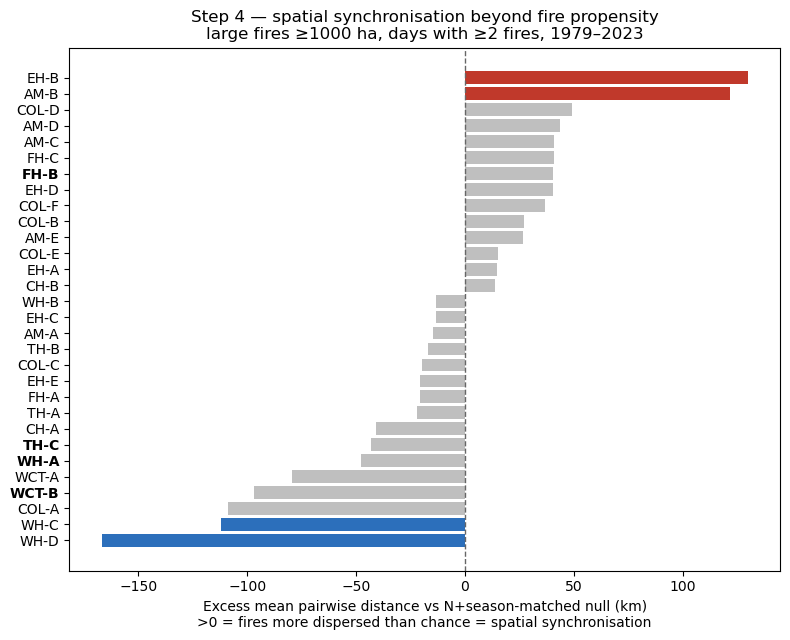

saved sync_excess_distance.png


In [13]:
# Step 4 plot — excess spatial spread vs the N+season-matched null
fig, ax = plt.subplots(figsize=(8, 6.5))
dd = spread.sort_values("excess")
def _col(s, e):
    if s and e > 0: return "#c0392b"   # more dispersed than chance (synchronisation)
    if s and e < 0: return "#2c6fbb"   # more clustered than chance
    return "0.75"
ax.barh(dd["assigned_SWT"], dd["excess"], color=[_col(s, e) for s, e in zip(dd.sig_fdr, dd.excess)])
ax.axvline(0, ls="--", color="0.4", lw=1)
for lab in ["FH-B", "WH-A", "TH-C", "WCT-B"]:
    if lab in set(dd["assigned_SWT"]):
        ax.get_yticklabels()[list(dd["assigned_SWT"]).index(lab)].set_fontweight("bold")
ax.set_xlabel("Excess mean pairwise distance vs N+season-matched null (km)\n>0 = fires more dispersed than chance = spatial synchronisation")
ax.set_title(f"Step 4 — spatial synchronisation beyond fire propensity\nlarge fires ≥{MIN_AREA_HA} ha, days with ≥2 fires, {swt_min.year}–{swt_max.year}")
fig.tight_layout()
fig.savefig(f"{DATA_DIR}/sync_excess_distance.png", dpi=150)
plt.show()
print("saved sync_excess_distance.png")

## Step 5 — Region-pair co-occurrence

Step 4 found no broad *spatial spreading* under the headline SWTs. But an SWT could still favour **specific region combinations** (e.g. SA + Tasmania together) without changing the average spread. This step tests that directly.

**Test.** For each state-pair (21 possible from NSW/VIC/QLD/SA/WA/TAS/NT) and each SWT, the rate at which *both* states are burning on the same day. Compared to an **amount-matched null**: within strata of (month × number-of-states-burning), permute the SWT day-labels 1000×. So we ask — *given that k regions are burning, does this SWT make it disproportionately this particular pair, rather than other combinations?* Two-sided, FDR-corrected over the 4 headline SWTs × 21 pairs = 84 tests.

A positive, significant pair means genuine spatial coordination of that specific region combination — the one way a synchronisation signal could survive Step 4's null result.

In [14]:
# ---- Step 5: per-day burning-STATE set (all footprints, as in Step 2) ----
from itertools import combinations
STATES = ["NSW", "VIC", "QLD", "SA", "WA", "TAS", "NT"]   # ACT folded into NSW

# which states are burning each day = ANY footprint of that state (footprint-level, matches Step 2)
state_days = pd.DataFrame({
    "day":   np.repeat(ig, dur) + offs,
    "state": np.repeat(large["state"].values, dur),
}).drop_duplicates()
burn = (state_days.assign(v=1)
        .pivot_table(index="day", columns="state", values="v", fill_value=0)
        .reindex(columns=STATES, fill_value=0))
burn["n_states"] = burn.sum(axis=1)
burn = burn.reset_index().merge(swt[["day", "month", "assigned_SWT"]], on="day", how="left")
pair_days = burn[(burn["n_states"] >= 2) & burn["assigned_SWT"].notna()].copy()

# day x pair co-occurrence matrix (1 if both states of the pair are burning that day)
PAIRS = list(combinations(STATES, 2))
Sarr  = pair_days[STATES].to_numpy()
pidx  = [(STATES.index(a), STATES.index(b)) for a, b in PAIRS]
M = np.stack([Sarr[:, i] * Sarr[:, j] for i, j in pidx], axis=1).astype(float)

print(f">=2-state days (matches Step 2 multi-day count): {len(pair_days):,}")
cnt = M.sum(0)
print("most common co-occurring state pairs (raw counts):")
for k in np.argsort(cnt)[::-1][:6]:
    print(f"   {PAIRS[k][0]}-{PAIRS[k][1]}: {int(cnt[k]):,} days")

>=2-state days (matches Step 2 multi-day count): 6,389
most common co-occurring state pairs (raw counts):
   QLD-WA: 3,420 days
   NSW-QLD: 3,168 days
   NSW-WA: 2,339 days
   QLD-SA: 1,532 days
   SA-WA: 1,459 days
   NSW-SA: 1,109 days


In [15]:
# ---- amount-matched label-permutation test, per (SWT, state-pair) ----
def pair_permutation(pair_days, M, PAIRS, B=N_BOOT, seed=0):
    d = pair_days.reset_index(drop=True)
    codes, items = pd.factorize(d["assigned_SWT"], sort=True)
    K, P = len(items), len(PAIRS)
    n_k = np.bincount(codes, minlength=K).astype(float)
    # strata = month x n_states (how many regions burning): permute SWT labels within each
    strat  = d["month"].astype(str) + "|" + d["n_states"].astype(str)
    strata = [np.where(strat.values == s)[0] for s in strat.unique()]

    obs = np.zeros((K, P)); np.add.at(obs, codes, M); obs /= n_k[:, None]
    rng = np.random.default_rng(seed)
    ge = np.zeros((K, P)); le = np.zeros((K, P)); ssum = np.zeros((K, P))
    for b in range(B):
        perm = codes.copy()
        for idx in strata:
            perm[idx] = codes[idx][rng.permutation(idx.size)]
        rate = np.zeros((K, P)); np.add.at(rate, perm, M); rate /= n_k[:, None]
        ge += rate >= obs; le += rate <= obs; ssum += rate
    null_mean = ssum / B
    pval = np.minimum(2 * np.minimum(ge, le) / B, 1.0)
    rows = [(items[si], f"{PAIRS[pi][0]}-{PAIRS[pi][1]}", int(n_k[si]),
             obs[si, pi], null_mean[si, pi], obs[si, pi] - null_mean[si, pi], pval[si, pi])
            for si in range(K) for pi in range(P)]
    return pd.DataFrame(rows, columns=["assigned_SWT", "pair", "n_days",
                                       "obs", "null_mean", "excess", "pval"])

HEAD = ["FH-B", "WH-A", "TH-C", "WCT-B"]
pair_res = pair_permutation(pair_days, M, PAIRS)
sub = pair_res[pair_res.assigned_SWT.isin(HEAD)].copy()
sub["sig_fdr"], _, _, _ = multipletests(np.clip(sub["pval"], 1e-4, 1), 0.05, method="fdr_bh")

print("=== Step 5: region-pair co-occurrence vs amount+season-matched null "
      "(headline SWTs, FDR over 4x21=84 tests) ===")
for s in HEAD:
    t = sub[sub.assigned_SWT == s].sort_values("excess", ascending=False)
    sig = t[t.sig_fdr]
    print(f"\n{s} (n_days={t.n_days.iloc[0]}):")
    if sig.empty:
        r = t.iloc[0]
        print(f"   no pair survives FDR; strongest: {r.pair} "
              f"excess {r.excess:+.3f} (p={r.pval:.3f})")
    else:
        for r in sig.itertuples():
            word = "MORE" if r.excess > 0 else "LESS"
            print(f"   {r.pair:>8}: burn together {word} than chance "
                  f"({r.obs:.3f} vs {r.null_mean:.3f}, excess {r.excess:+.3f}, p={r.pval:.3f})")
print(f"\ntotal FDR-significant pairs across the 84 tests: {int(sub.sig_fdr.sum())}")

=== Step 5: region-pair co-occurrence vs amount+season-matched null (headline SWTs, FDR over 4x21=84 tests) ===

FH-B (n_days=233):
   no pair survives FDR; strongest: NSW-QLD excess +0.040 (p=0.162)

WH-A (n_days=323):
   no pair survives FDR; strongest: QLD-TAS excess +0.025 (p=0.124)

TH-C (n_days=280):
   no pair survives FDR; strongest: VIC-QLD excess +0.041 (p=0.028)

WCT-B (n_days=144):
   no pair survives FDR; strongest: QLD-SA excess +0.056 (p=0.016)

total FDR-significant pairs across the 84 tests: 0


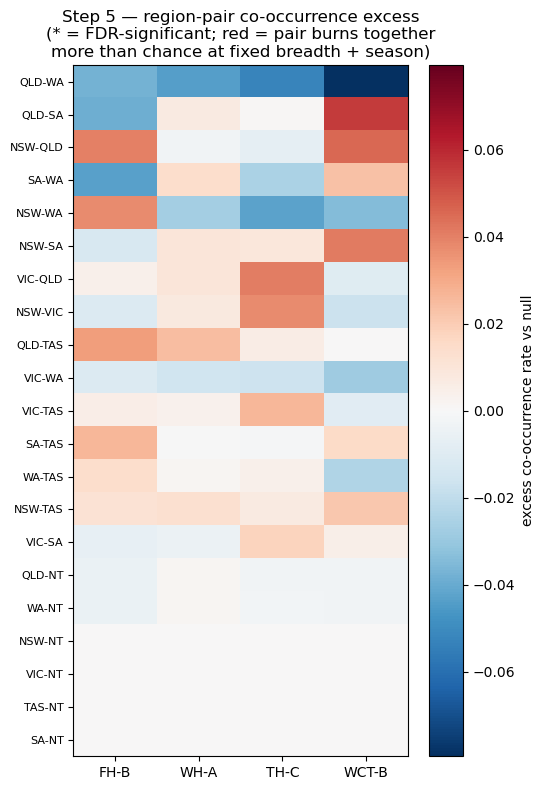

saved region_pair_excess.png


In [16]:
# Step 5 plot — region-pair co-occurrence excess heatmap (headline SWTs)
piv  = sub.pivot(index="pair", columns="assigned_SWT", values="excess").reindex(columns=HEAD)
sigp = sub.pivot(index="pair", columns="assigned_SWT", values="sig_fdr").reindex(columns=HEAD).fillna(False)
order = piv.abs().max(axis=1).sort_values(ascending=False).index   # most-variable pairs on top
piv, sigp = piv.reindex(order), sigp.reindex(order)

fig, ax = plt.subplots(figsize=(5.5, 8))
vmax = np.nanmax(np.abs(piv.values))
im = ax.imshow(piv.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(HEAD))); ax.set_xticklabels(HEAD)
ax.set_yticks(range(len(piv)));  ax.set_yticklabels(piv.index, fontsize=8)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        if bool(sigp.values[i, j]):
            ax.text(j, i, "*", ha="center", va="center", fontweight="bold")
fig.colorbar(im, ax=ax, label="excess co-occurrence rate vs null")
ax.set_title("Step 5 — region-pair co-occurrence excess\n(* = FDR-significant; red = pair burns together\nmore than chance at fixed breadth + season)")
fig.tight_layout()
fig.savefig(f"{DATA_DIR}/region_pair_excess.png", dpi=150)
plt.show()
print("saved region_pair_excess.png")

## Step 6 — ERA5 circulation composites per SWT

Composite ERA5 (rt52, 12 UTC) circulation for each SWT, as day-of-year anomalies, to show the synoptic pattern behind the elevated fire AMOUNT (Steps 2-5) and inspect FH-B's SA-TAS coupling and TH-C's multi-state spread. Fields: **MSLP** (raw contours), **850 hPa wind anomaly** (quivers), **T850 anomaly** (shading); stippling where p<0.05.

Composites are computed **on Gadi** (`gadi/era5_swt_composites.py`, see `gadi/README_RUN.md`) and the small result `era5_swt_composites.nc` is copied back. The cell below reads it with `netCDF4` (local `xarray`/`dask` is broken) and **auto-falls back to a synthetic placeholder** until the real file is present.

using era5_swt_composites.nc (real Gadi output)


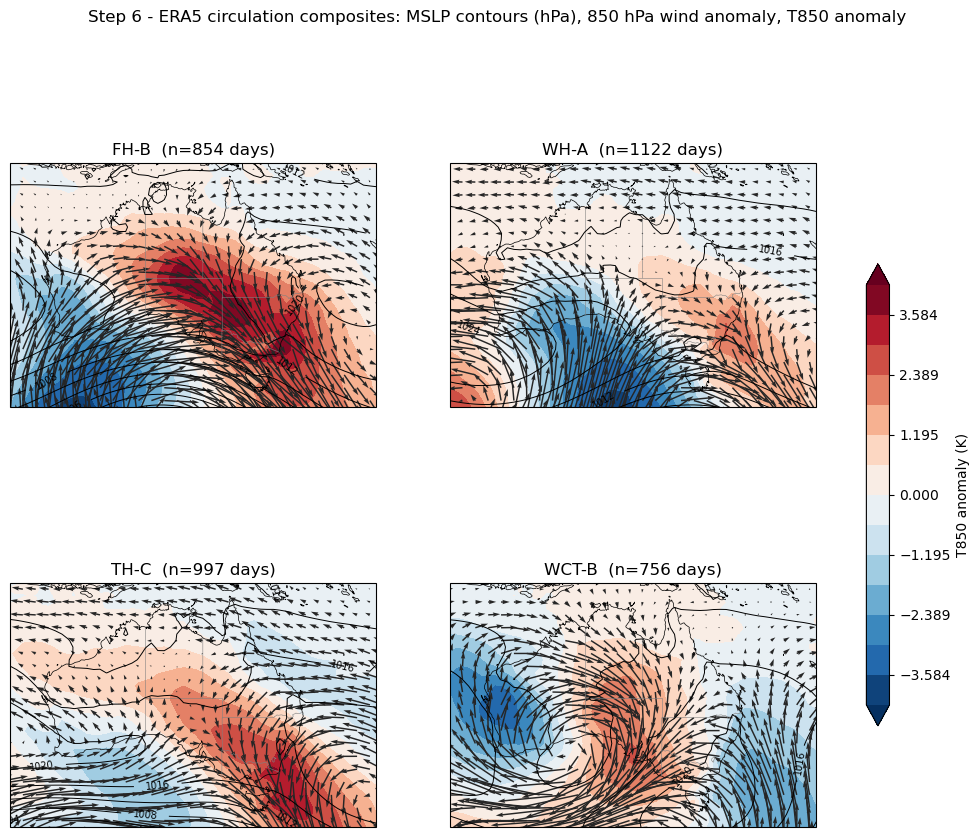

saved swt_circulation_composites.png


In [17]:
# Step 6 - plot ERA5 SWT circulation composites (Australia-zoomed, with state borders).
# Reads NetCDF via netCDF4 (local xarray/dask metadata is broken). Auto-uses the real Gadi
# output once it's in DATA_DIR; otherwise shows the synthetic placeholder.
import os, numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import cartopy.crs as ccrs
from cartopy.feature import LAND, NaturalEarthFeature

real  = f"{DATA_DIR}/era5_swt_composites.nc"
synth = f"{DATA_DIR}/era5_swt_composites_SYNTH.nc"
NC = real if os.path.exists(real) else synth
print("using", os.path.basename(NC), "(real Gadi output)" if NC == real else "(SYNTHETIC placeholder)")

nc = Dataset(NC)
swt_list = [str(s) for s in nc.variables["swt"][:]]
lon = nc.variables["lon"][:]; lat = nc.variables["lat"][:]
def comp(var, swt): return nc.variables[var][swt_list.index(swt)]
states = NaturalEarthFeature("cultural", "admin_1_states_provinces_lines", "50m", facecolor="none")

HEAD = ["FH-B", "WH-A", "TH-C", "WCT-B"]
vmax = max(float(np.nanmax(np.abs(comp("t850_anom", s)))) for s in HEAD)
fig, axes = plt.subplots(2, 2, figsize=(13, 10), subplot_kw=dict(projection=ccrs.PlateCarree()))
for ax, s in zip(axes.ravel(), HEAD):
    ax.add_feature(LAND, facecolor="0.95"); ax.coastlines(linewidth=0.5)
    ax.add_feature(states, edgecolor="0.5", linewidth=0.4)
    tr = dict(transform=ccrs.PlateCarree())
    cf = ax.contourf(lon, lat, comp("t850_anom", s), levels=np.linspace(-vmax, vmax, 15),
                     cmap="RdBu_r", extend="both", **tr)
    c = ax.contour(lon, lat, comp("msl_mean", s) / 100, levels=np.arange(980, 1040, 4),
                   colors="k", linewidths=0.7, **tr)
    if any(len(seg) for seg in c.allsegs): ax.clabel(c, fontsize=7, fmt="%d")
    st = 2
    ax.quiver(lon[::st], lat[::st], comp("u850_anom", s)[::st, ::st], comp("v850_anom", s)[::st, ::st],
              scale=60, width=0.004, color="0.15", **tr)
    ax.set_extent([108, 165, -46, -8], crs=ccrs.PlateCarree())
    ax.set_title(f"{s}  (n={int(comp('n_days', s))} days)", fontsize=12)
fig.colorbar(cf, ax=axes, label="T850 anomaly (K)", shrink=0.6)
fig.suptitle("Step 6 - ERA5 circulation composites: MSLP contours (hPa), 850 hPa wind anomaly, T850 anomaly")
fig.savefig(f"{DATA_DIR}/swt_circulation_composites.png", dpi=160, bbox_inches="tight")
plt.show()
print("saved swt_circulation_composites.png")
nc.close()

## Step 7 - Figures in R / ggplot

The statistical panels (Steps 2-5) and the circulation maps (Step 6) are re-rendered in **ggplot2** for a consistent, thesis-ready look. Computation stays in Python (validated); R only reads the exported results.

R runs in a dedicated conda env **`rfigs`** (`r-base` 4.5 + tidyverse + metR + sf + rnaturalearth). It's driven from the notebook via the `rfigs` `Rscript` (we shell out rather than use rpy2: on this macOS box rpy2's binary keeps linking to a non-existent CRAN R *framework* path and won't bind to the conda R). The two cells below hold the R source (`%%writefile` writes them to `R/`), and the last cell runs them and shows the figures inline.

Inputs: `R/*.csv` (written by `R/export_results_for_r.py`) and `era5_swt_composites.nc`.

In [18]:
%%writefile /Users/smar0095/Fires_SWTs/R/figures.R
# Fires x SWT — statistical figures in ggplot2.
# Run: /opt/anaconda3/envs/rfigs/bin/Rscript figures.R
suppressMessages(library(tidyverse))

base <- "/Users/smar0095/Fires_SWTs/R"
figs <- file.path(base, "figs"); dir.create(figs, showWarnings = FALSE)

elev_col <- "#c0392b"; supp_col <- "#2c6fbb"; ns_col <- "grey70"
theme_set(theme_bw(base_size = 12))

# ---- Figure 1: SWT-level relative risk of a multi-state fire day (Step 2) ----
swt <- read_csv(file.path(base, "swt_rr.csv"), show_col_types = FALSE) |>
  mutate(cat = case_when(sig_fdr & RR_mean > 1 ~ "Elevated (FDR)",
                         sig_fdr & RR_mean < 1 ~ "Suppressed (FDR)",
                         TRUE ~ "n.s."),
         assigned_SWT = fct_reorder(assigned_SWT, RR_mean))

p1 <- ggplot(swt, aes(RR_mean, assigned_SWT, colour = cat)) +
  geom_vline(xintercept = 1, linetype = "dashed", colour = "grey50") +
  geom_segment(aes(x = CI_low, xend = CI_high, yend = assigned_SWT), linewidth = 0.5) +
  geom_point(size = 2) +
  scale_colour_manual(values = c("Elevated (FDR)" = elev_col,
                                 "Suppressed (FDR)" = supp_col, "n.s." = ns_col)) +
  labs(x = "Relative risk of a >=2-state fire day (seasonally matched)",
       y = NULL, colour = NULL, title = "Multi-state fire days by synoptic weather type") +
  theme(legend.position = "top")
ggsave(file.path(figs, "fig_swt_rr.png"), p1, width = 7, height = 8, dpi = 200)

# ---- Figure 2: spatial spread beyond fire propensity (Step 4) ----
s4 <- read_csv(file.path(base, "step4_distance.csv"), show_col_types = FALSE) |>
  mutate(cat = case_when(sig_fdr & excess > 0 ~ "More dispersed (FDR)",
                         sig_fdr & excess < 0 ~ "More clustered (FDR)",
                         TRUE ~ "n.s."),
         assigned_SWT = fct_reorder(assigned_SWT, excess))

p2 <- ggplot(s4, aes(excess, assigned_SWT, fill = cat)) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey50") +
  geom_col() +
  scale_fill_manual(values = c("More dispersed (FDR)" = elev_col,
                               "More clustered (FDR)" = supp_col, "n.s." = ns_col)) +
  labs(x = "Excess mean pairwise distance vs N+season-matched null (km)\n(>0 = more dispersed = synchronisation)",
       y = NULL, fill = NULL, title = "Spatial spread beyond fire propensity (Step 4)") +
  theme(legend.position = "top")
ggsave(file.path(figs, "fig_step4_distance.png"), p2, width = 7, height = 8, dpi = 200)

# ---- Figure 3: region-pair co-occurrence excess heatmap (Step 5) ----
p5 <- read_csv(file.path(base, "step5_pairs.csv"), show_col_types = FALSE) |>
  mutate(star = ifelse(sig_fdr, "*", ""),
         assigned_SWT = factor(assigned_SWT, levels = c("FH-B", "WH-A", "TH-C", "WCT-B")),
         pair = fct_reorder(pair, abs(excess), .fun = max))

p3 <- ggplot(p5, aes(assigned_SWT, pair, fill = excess)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = star), size = 6, vjust = 0.78) +
  scale_fill_gradient2(low = supp_col, mid = "white", high = elev_col, midpoint = 0) +
  labs(x = NULL, y = "state pair", fill = "excess\nco-occur.",
       title = "Region-pair co-occurrence excess (Step 5)",
       subtitle = "* = FDR-significant;  red = burn together more than chance") +
  theme_minimal(base_size = 12)
ggsave(file.path(figs, "fig_step5_pairs.png"), p3, width = 5.5, height = 7, dpi = 200)

cat("wrote 3 figures to", figs, "\n")


Overwriting /Users/smar0095/Fires_SWTs/R/figures.R


In [19]:
%%writefile /Users/smar0095/Fires_SWTs/R/maps.R
# ERA5 SWT circulation composites in ggplot (metR + sf). Reads era5_swt_composites.nc.
# Run: /opt/anaconda3/envs/rfigs/bin/Rscript maps.R
suppressMessages({library(ncdf4); library(tidyverse); library(metR); library(sf); library(rnaturalearth)})

base <- "/Users/smar0095/Fires_SWTs"
figs <- file.path(base, "R", "figs"); dir.create(figs, showWarnings = FALSE, recursive = TRUE)
ncf <- file.path(base, "era5_swt_composites.nc")
if (!file.exists(ncf)) ncf <- file.path(base, "era5_swt_composites_SYNTH.nc")
cat("reading", basename(ncf), "\n")

nc  <- nc_open(ncf)
swt <- ncvar_get(nc, "swt"); lon <- ncvar_get(nc, "lon"); lat <- ncvar_get(nc, "lat")
nd  <- ncvar_get(nc, "n_days")
# netcdf dims (swt,lat,lon) -> ncdf4 returns R array dims (lon,lat,swt)
t850 <- ncvar_get(nc, "t850_anom"); msl <- ncvar_get(nc, "msl_mean")
u850 <- ncvar_get(nc, "u850_anom"); v850 <- ncvar_get(nc, "v850_anom")
nc_close(nc)

HEAD <- c("FH-B", "WH-A", "TH-C", "WCT-B")
grid <- expand.grid(lon = lon, lat = lat)            # lon varies fastest (matches column-major slice)
mk <- function(s) {
  i <- which(swt == s)
  tibble(lon = grid$lon, lat = grid$lat,
         t850 = as.vector(t850[, , i]), msl = as.vector(msl[, , i]) / 100,
         u = as.vector(u850[, , i]), v = as.vector(v850[, , i]),
         swt = s, lab = sprintf("%s  (n=%d days)", s, nd[i]))
}
df <- bind_rows(lapply(HEAD, mk))
df$lab <- factor(df$lab, levels = unique(df$lab[order(match(df$swt, HEAD))]))

coast <- ne_countries(scale = "medium", returnclass = "sf")
vmax  <- max(abs(df$t850), na.rm = TRUE)

p <- ggplot(df, aes(lon, lat)) +
  geom_contour_fill(aes(z = t850), na.fill = TRUE,
                    breaks = seq(-ceiling(vmax), ceiling(vmax), length.out = 13)) +
  geom_contour(aes(z = msl), colour = "grey20", linewidth = 0.3,
               breaks = seq(980, 1040, 4)) +
  geom_arrow(aes(dx = u * 0.3, dy = v * 0.3), skip = 3, colour = "grey15",
             arrow.length = 0.3, min.mag = 0.5) +
  geom_sf(data = coast, fill = NA, colour = "black", linewidth = 0.35, inherit.aes = FALSE) +
  coord_sf(xlim = c(108, 165), ylim = c(-46, -8), expand = FALSE) +
  facet_wrap(~lab) +
  scale_fill_gradient2(low = "#2c6fbb", mid = "white", high = "#c0392b",
                       midpoint = 0, name = "T850\nanom (K)") +
  labs(x = NULL, y = NULL,
       title = "ERA5 circulation composites by SWT",
       subtitle = "Filled: 850 hPa temperature anomaly | contours: MSLP (hPa) | arrows: 850 hPa wind anomaly") +
  theme_bw(base_size = 11) +
  theme(panel.grid = element_line(colour = "grey92"))

ggsave(file.path(figs, "fig_circulation_composites.png"), p, width = 11, height = 8.5, dpi = 200)
cat("wrote fig_circulation_composites.png\n")


Overwriting /Users/smar0095/Fires_SWTs/R/maps.R


ANALYSIS PERIOD (FFDI overlap): 1979-01-01 -> 2023-12-31
wrote: regime_rr, swt_rr, step4_distance, step5_pairs, swt_danger_rr, step8_danger_pairs -> /Users/smar0095/Fires_SWTs/R


--- figures.R (exit 0) ---
wrote 3 figures to /Users/smar0095/Fires_SWTs/R/figs


--- maps.R (exit 0) ---
reading era5_swt_composites.nc 
wrote fig_circulation_composites.png


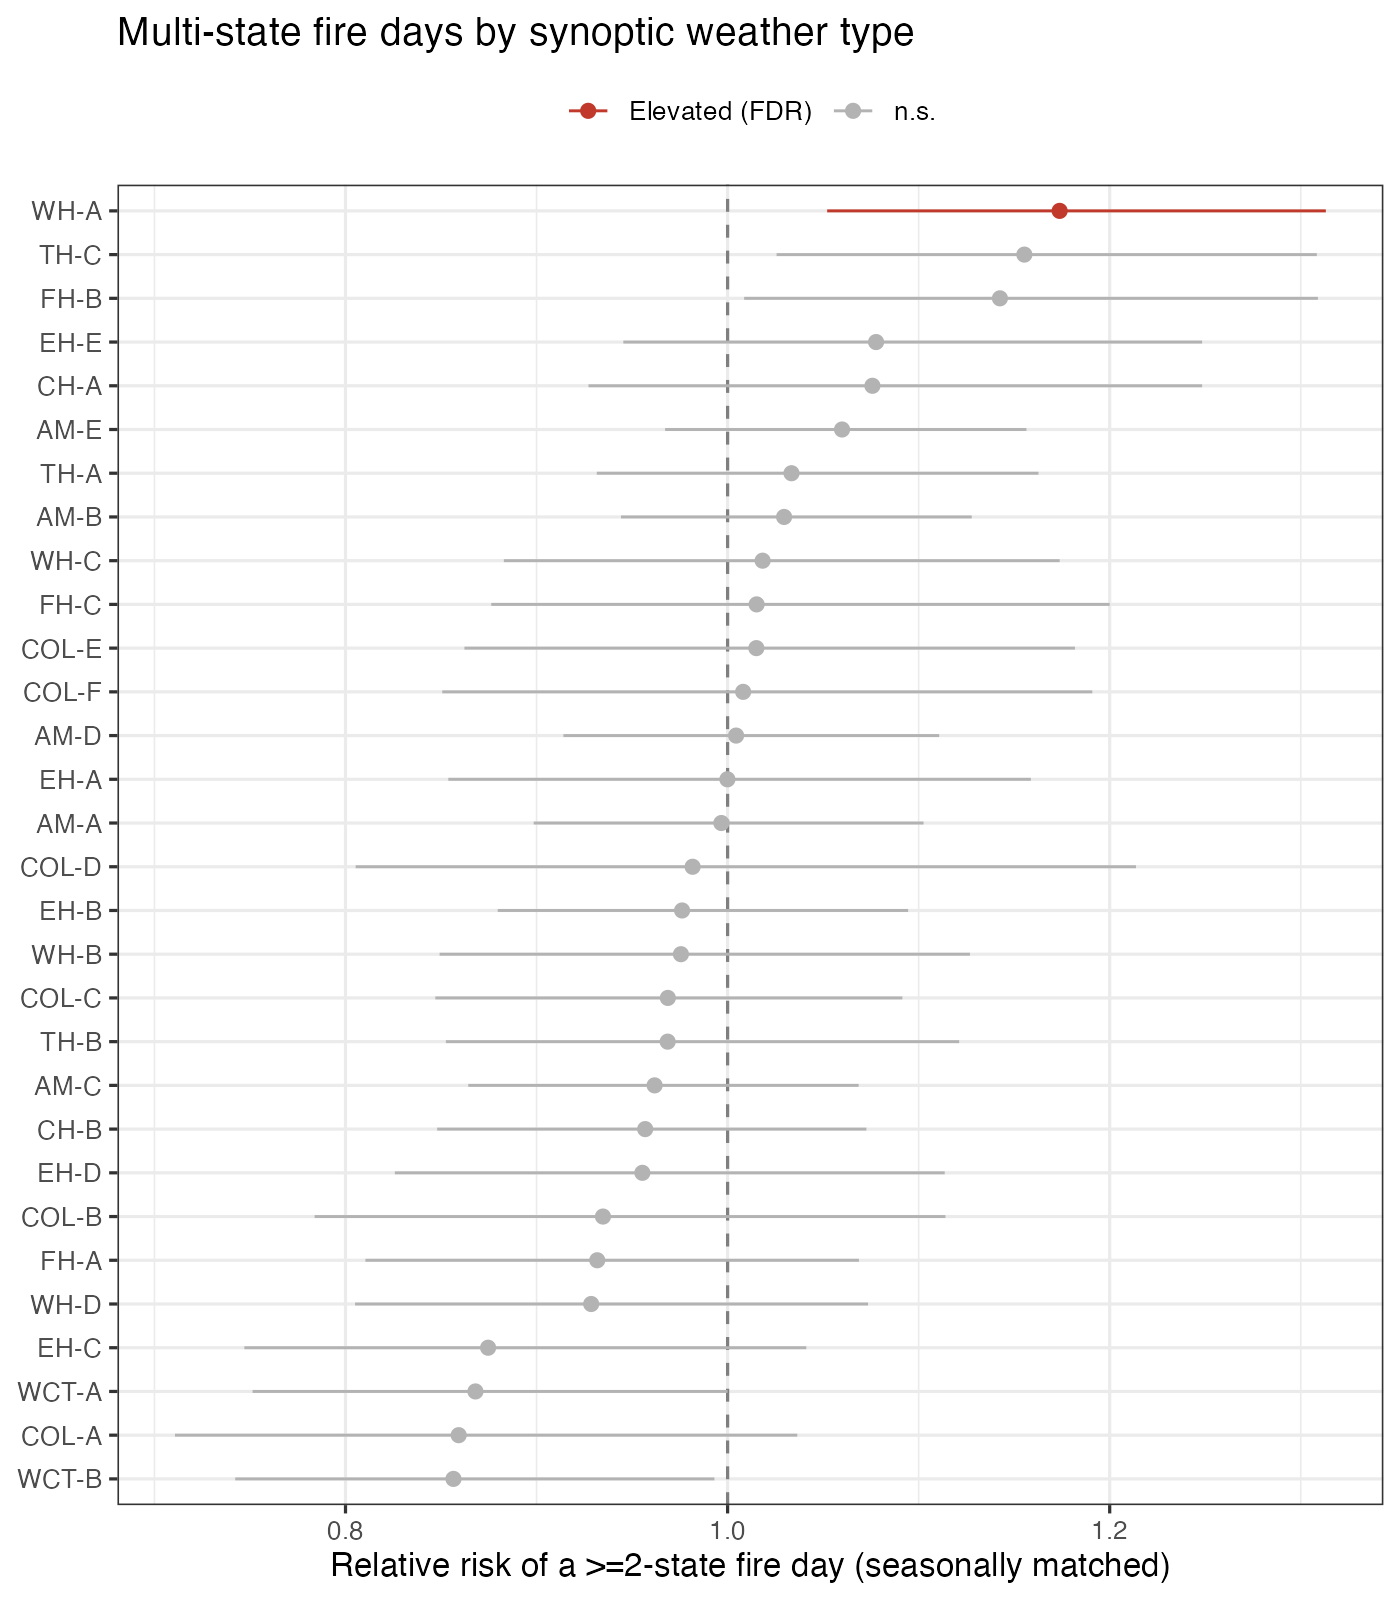

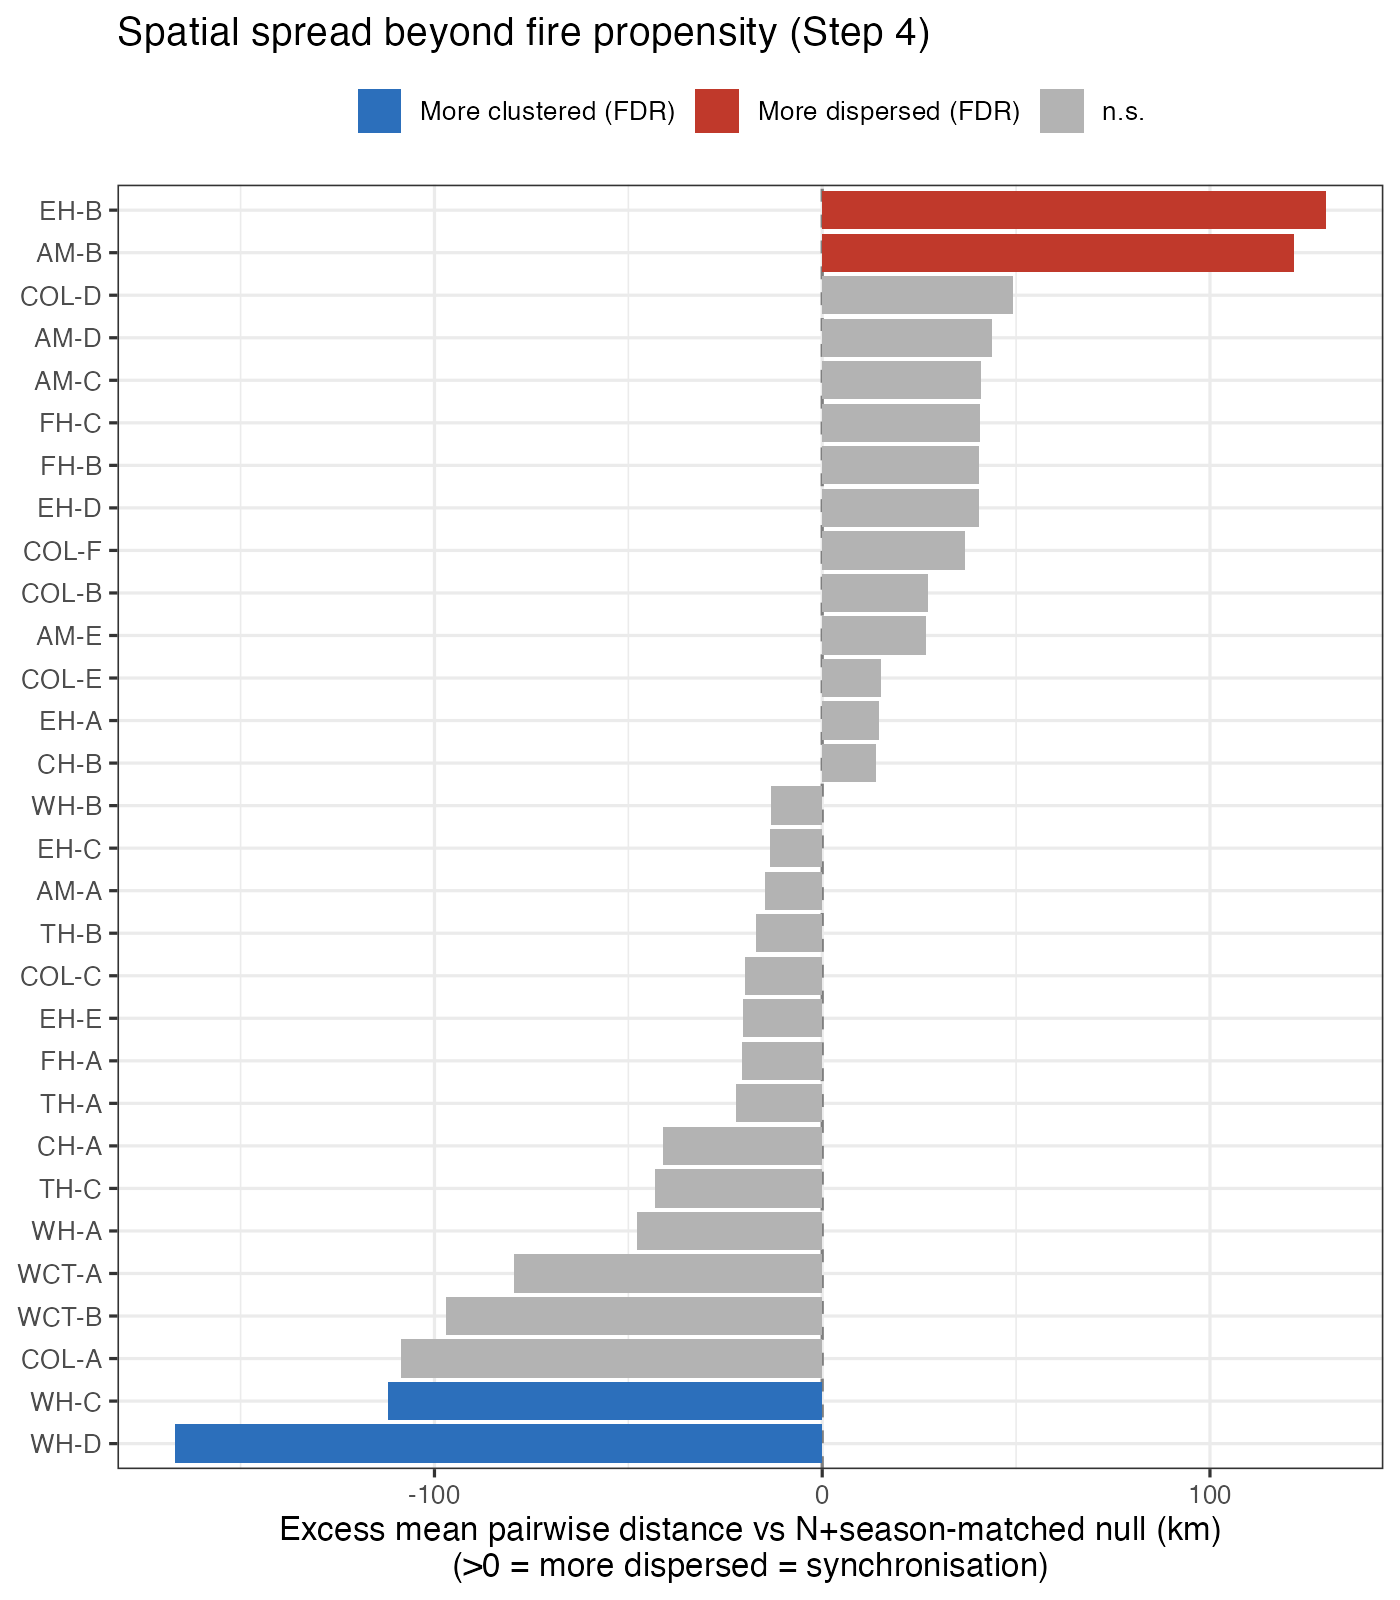

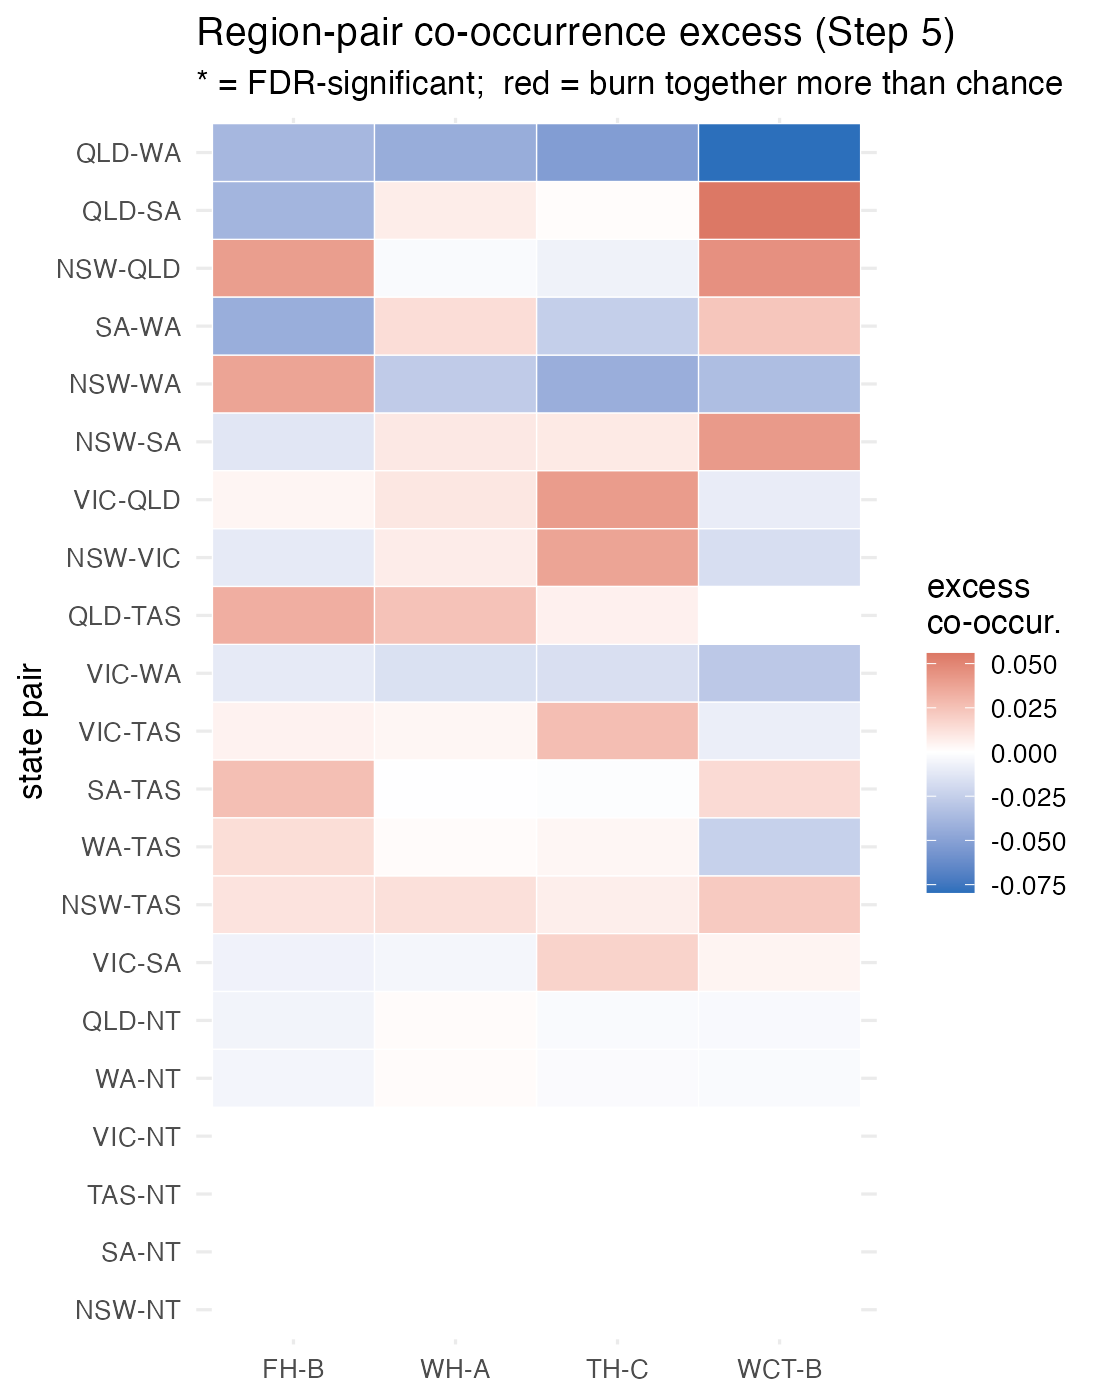

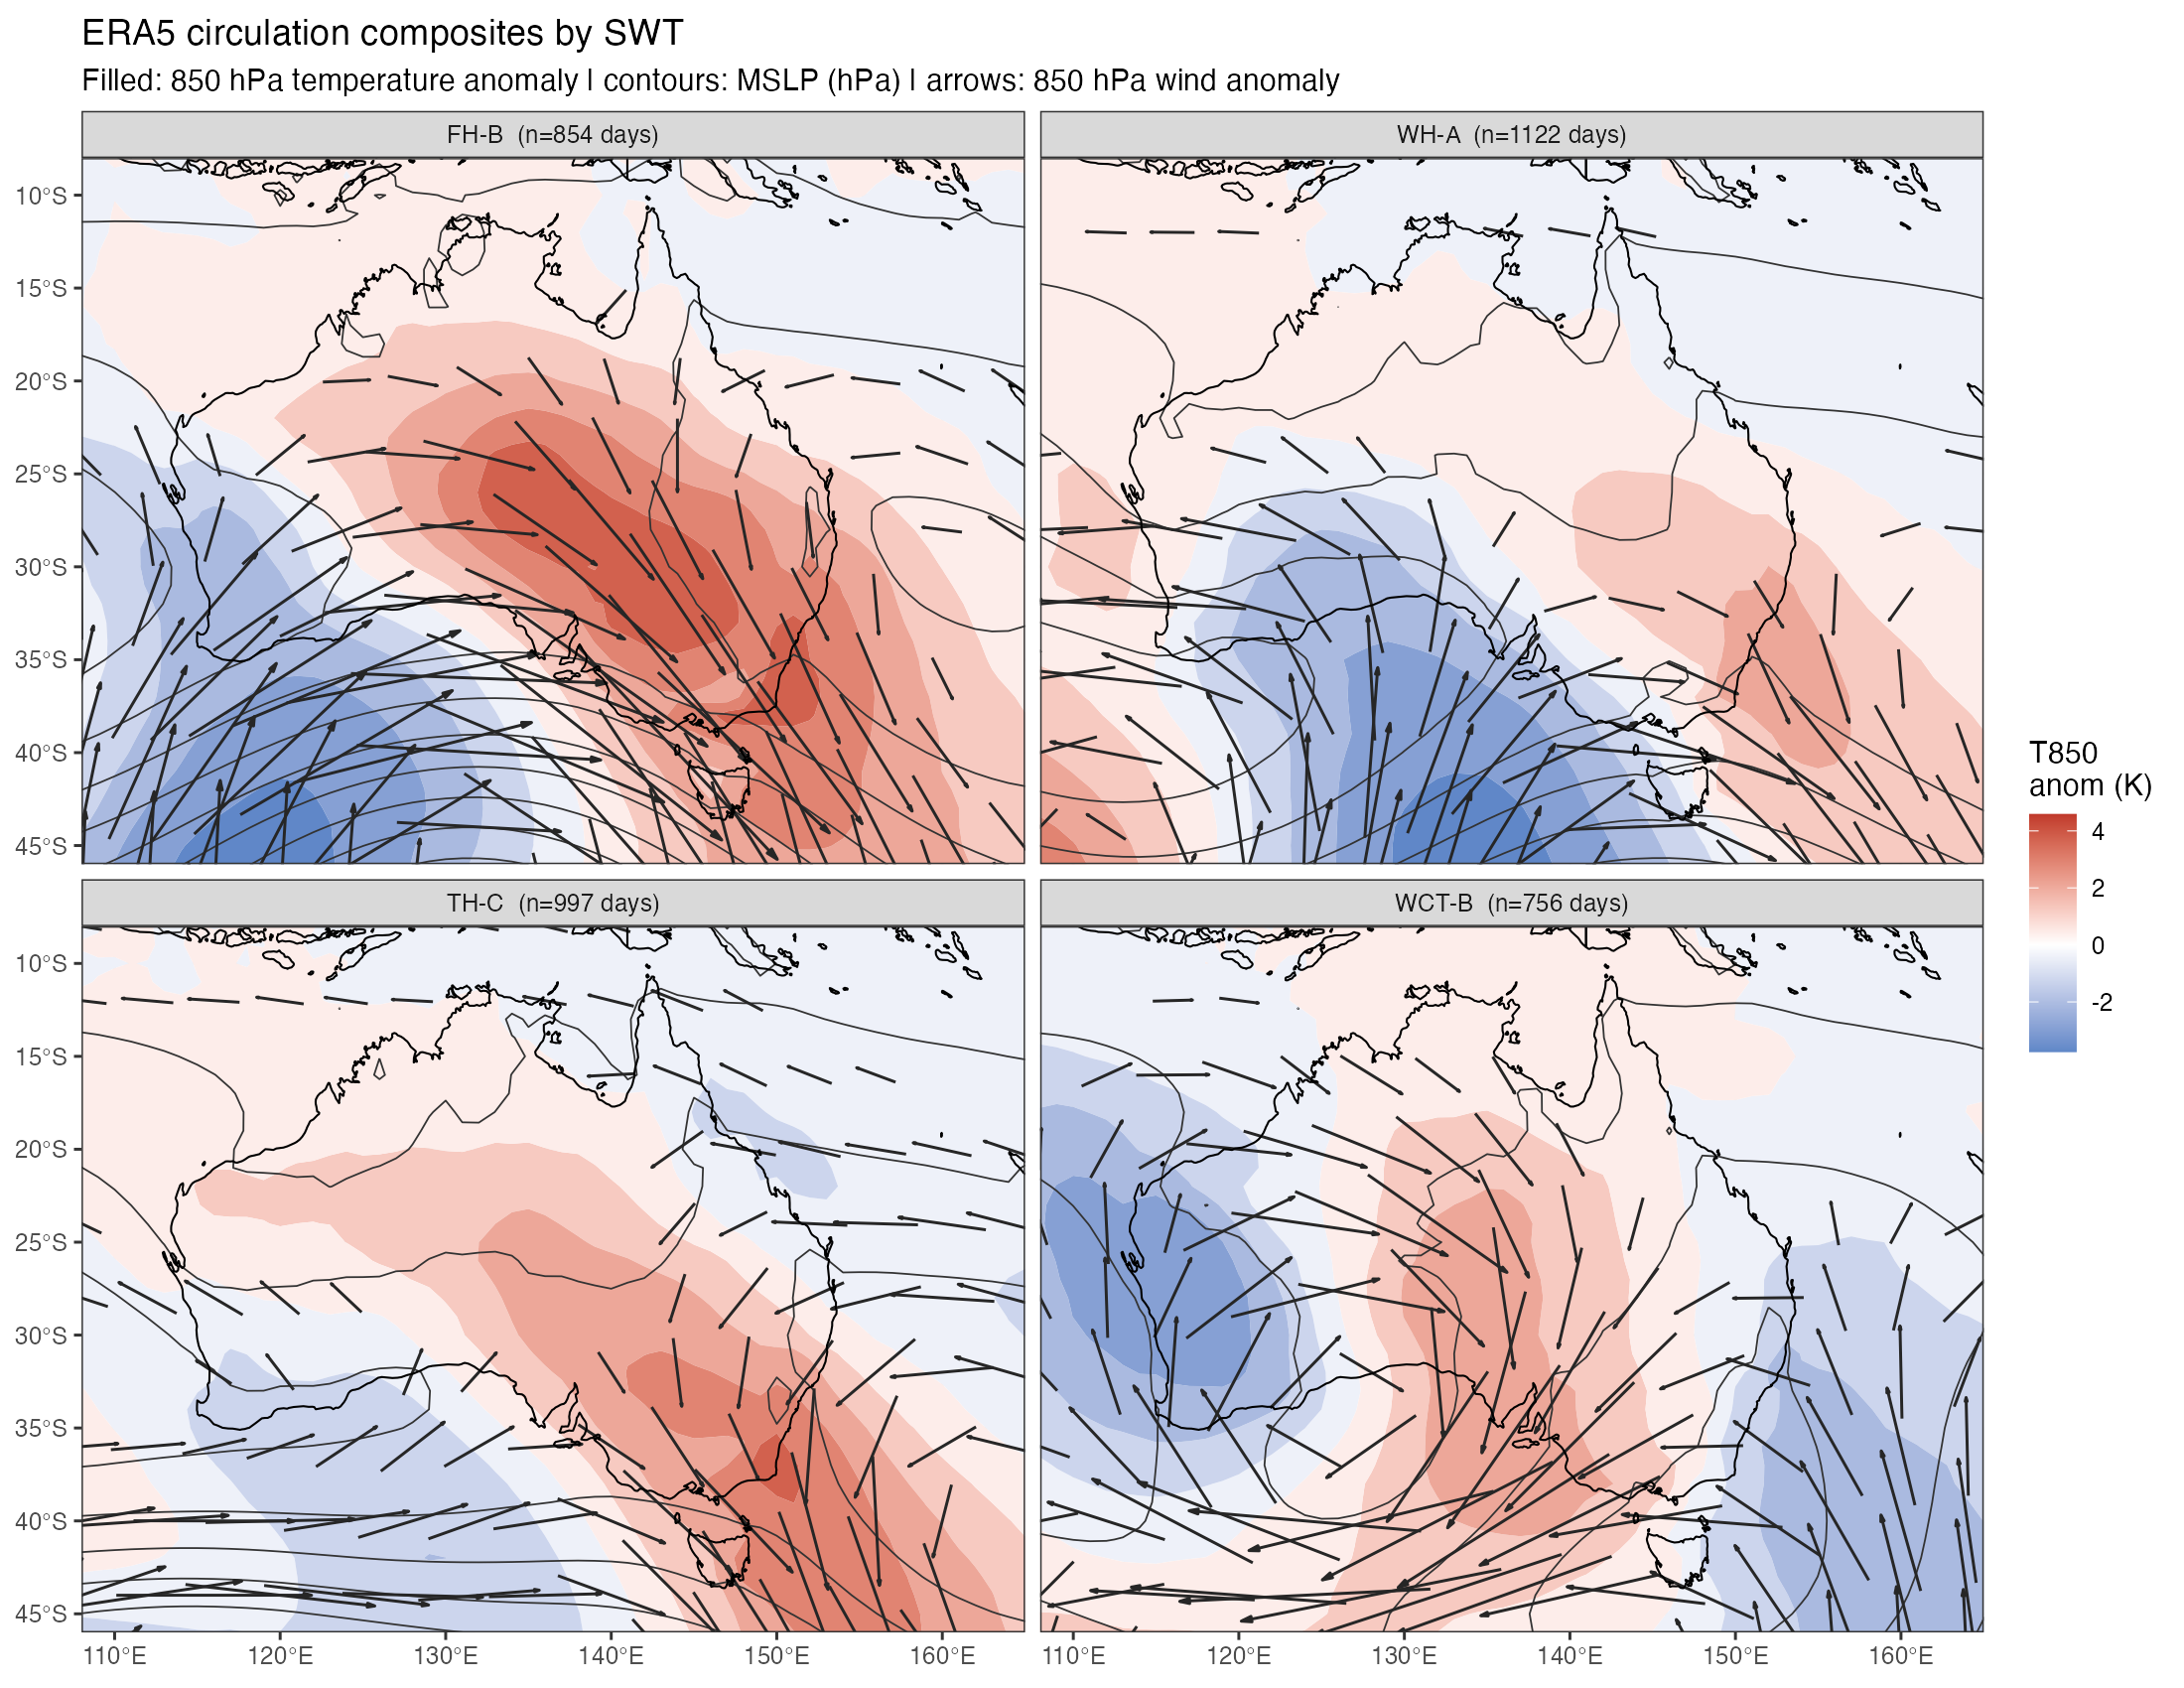

In [20]:
# Run the R scripts in the rfigs env and display the ggplot figures inline.
import subprocess
from IPython.display import Image, display
RSCRIPT = "/opt/anaconda3/envs/rfigs/bin/Rscript"
RDIR = f"{DATA_DIR}/R"
for script in ["export_results_for_r.py"]:                      # refresh CSVs from current analysis
    subprocess.run(["/opt/anaconda3/bin/python3", script], cwd=RDIR, check=True)
for script in ["figures.R", "maps.R"]:
    r = subprocess.run([RSCRIPT, script], cwd=RDIR, capture_output=True, text=True)
    msg = r.stdout.strip() or r.stderr.strip()[-400:]
    print(f"--- {script} (exit {r.returncode}) ---\n{msg}")
for png in ["fig_swt_rr.png", "fig_step4_distance.png", "fig_step5_pairs.png", "fig_circulation_composites.png"]:
    display(Image(filename=f"{RDIR}/figs/{png}"))

## Step 8 - FFDI fire danger (BARRA-R2)

The cleanest test of the thesis: **does synoptic type synchronise fire DANGER across states, even though it didn't synchronise realized fire?** FFDI (BARRA-R2-derived, daily, 1979-) is the unconfounded atmospheric signal.

A state has a **high-danger day** when its area-mean FFDI exceeds its own **monthly 90th percentile** (self-normalising by state & season). We then re-run the **Step 2** (multi-state RR) and **Step 5** (region-pair) machinery on *danger*, and composite the FFDI anomaly per SWT.

Inputs are computed on Gadi (`gadi/ffdi_extract.py` -> `ffdi_state_daily.csv` + `ffdi_swt_composite.nc`; see `gadi/README_FFDI.md`). **These are SYNTHETIC placeholders until the real Gadi files are rsynced in (same names).**

In [21]:
# Step 8 build - FFDI high-danger days + danger multi-state RR (reuses simultaneity_rr).
import sys
if f"{DATA_DIR}/gadi" not in sys.path: sys.path.append(f"{DATA_DIR}/gadi")
from ffdi_core import high_danger_flags, build_danger_daily

ffdi = pd.read_csv(f"{DATA_DIR}/ffdi_state_daily.csv")
flags = high_danger_flags(ffdi, q=0.90)
ddaily = build_danger_daily(flags, swt[["day", "month", "assigned_SWT", "regime"]], min_states=MIN_STATES)
print(f"FFDI high-danger days: >=1 state {100*(ddaily.n_states>=1).mean():.0f}%, "
      f">={MIN_STATES} states {100*ddaily.multi_day.mean():.0f}%  (n_days={len(ddaily):,})")

swt_danger_rr = simultaneity_rr("assigned_SWT", daily_df=ddaily, fdr=True)
print("\n=== Danger multi-state RR by SWT (seasonally matched, FDR) ===")
print(swt_danger_rr[["assigned_SWT", "n_multi", "p_multi", "RR_mean", "CI_low", "CI_high", "sig_fdr"]]
      .round(3).to_string(index=False))
print("\nElevated DANGER & survive FDR:",
      ", ".join(f"{r.assigned_SWT} ({r.RR_mean:.2f})"
                for r in swt_danger_rr[(swt_danger_rr.RR_mean > 1) & swt_danger_rr.sig_fdr].itertuples()) or "none")

FFDI high-danger days: >=1 state 37%, >=2 states 18%  (n_days=16,436)

=== Danger multi-state RR by SWT (seasonally matched, FDR) ===
assigned_SWT  n_multi  p_multi  RR_mean  CI_low  CI_high  sig_fdr
        FH-B      222    0.383    2.131   1.776    2.552     True
        TH-B      177    0.291    1.621   1.362    1.967     True
        TH-C      195    0.296    1.619   1.364    1.912     True
        FH-A      140    0.275    1.519   1.250    1.892     True
        AM-E      176    0.255    1.398   1.197    1.630     True
        WH-A      185    0.248    1.357   1.164    1.609     True
        EH-E      140    0.238    1.317   1.102    1.609     True
        WH-D      112    0.232    1.289   1.066    1.600     True
        EH-D       96    0.215    1.208   0.980    1.500    False
        WH-C      112    0.217    1.204   0.982    1.455    False
        CH-A      143    0.216    1.187   1.000    1.402    False
        AM-B      156    0.216    1.186   1.006    1.393    False
        

In [22]:
# Step 8 synchronisation - does DANGER co-occur in specific state-pairs? (reuses pair_permutation)
from itertools import combinations
STATES_D = ["NSW", "VIC", "QLD", "SA", "WA", "TAS", "NT"]
hot = flags[flags.hot].assign(v=1)
burn_d = (hot.pivot_table(index="date", columns="state", values="v", fill_value=0)
          .reindex(columns=STATES_D, fill_value=0))
burn_d["n_states"] = burn_d.sum(axis=1)
burn_d = burn_d.reset_index().rename(columns={"date": "day"}); burn_d["day"] = pd.to_datetime(burn_d["day"])
burn_d = burn_d.merge(swt[["day", "month", "assigned_SWT"]], on="day", how="left")
pair_days_d = burn_d[(burn_d.n_states >= 2) & burn_d.assigned_SWT.notna()].copy()
PAIRS_D = list(combinations(STATES_D, 2)); Sd = pair_days_d[STATES_D].to_numpy()
idx = [(STATES_D.index(a), STATES_D.index(b)) for a, b in PAIRS_D]
M_d = np.stack([Sd[:, i] * Sd[:, j] for i, j in idx], axis=1).astype(float)

res_d = pair_permutation(pair_days_d, M_d, PAIRS_D)
HEAD = ["FH-B", "WH-A", "TH-C", "WCT-B"]; subd = res_d[res_d.assigned_SWT.isin(HEAD)].copy()
subd["sig_fdr"], _, _, _ = multipletests(np.clip(subd.pval, 1e-4, 1), 0.05, method="fdr_bh")
print(f"=== DANGER region-pair synchronisation ({len(pair_days_d):,} >=2-danger-state days, FDR over {len(subd)}) ===")
sigd = subd[(subd.excess > 0) & subd.sig_fdr]
print("Pairs dangerous TOGETHER more than chance & FDR:",
      ", ".join(f"{r.assigned_SWT}:{r.pair} (+{r.excess:.3f})" for r in sigd.itertuples()) or "none")
for s in HEAD:
    t = subd[subd.assigned_SWT == s].sort_values("excess", ascending=False).iloc[0]
    print(f"  {s} strongest pair: {t.pair} excess {t.excess:+.3f} (p={t.pval:.3f})")

=== DANGER region-pair synchronisation (3,004 >=2-danger-state days, FDR over 84) ===
Pairs dangerous TOGETHER more than chance & FDR: FH-B:NSW-VIC (+0.147), FH-B:NSW-SA (+0.082), FH-B:VIC-QLD (+0.052), FH-B:VIC-SA (+0.155), TH-C:NSW-VIC (+0.093), TH-C:NSW-TAS (+0.072), TH-C:VIC-SA (+0.106), TH-C:VIC-TAS (+0.192), TH-C:VIC-NT (+0.050), TH-C:SA-TAS (+0.106), WCT-B:QLD-SA (+0.223), WCT-B:SA-NT (+0.153), WH-A:NSW-VIC (+0.094), WH-A:NSW-SA (+0.083)
  FH-B strongest pair: VIC-SA excess +0.155 (p=0.000)
  WH-A strongest pair: NSW-VIC excess +0.094 (p=0.000)
  TH-C strongest pair: VIC-TAS excess +0.192 (p=0.000)
  WCT-B strongest pair: QLD-SA excess +0.223 (p=0.000)


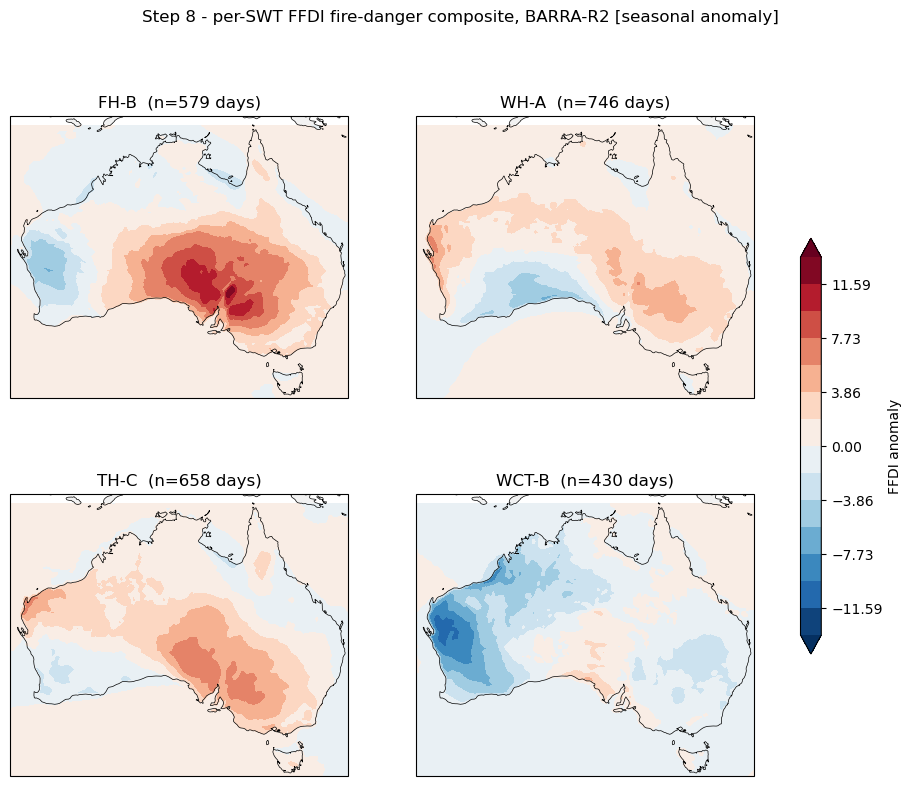

saved ffdi_swt_composite.png (seasonal anomaly)


In [23]:
# Step 8 map - per-SWT FFDI composite (BARRA-R2). Prefer seasonal anomaly; fall back to mean.
import numpy as np, matplotlib.pyplot as plt
from netCDF4 import Dataset
import cartopy.crs as ccrs
from cartopy.feature import LAND

nc = Dataset(f"{DATA_DIR}/ffdi_swt_composite.nc"); nc.set_auto_mask(False)
sl = [str(s) for s in nc.variables["swt"][:]]; lon = nc.variables["lon"][:]; lat = nc.variables["lat"][:]
HEAD = ["FH-B", "WH-A", "TH-C", "WCT-B"]
def grab(v, s): return np.asarray(nc.variables[v][sl.index(s)], float)

anom_ok = all(np.isfinite(grab("ffdi_anom", s)).any() for s in HEAD)
if anom_ok:                                   # proper seasonally-adjusted anomaly (needs the fixed nc)
    field_var, cmap, label, kind = "ffdi_anom", "RdBu_r", "FFDI anomaly", "seasonal anomaly"
    fa = lambda s: grab("ffdi_anom", s)
    vmax = max(float(np.nanmax(np.abs(fa(s)))) for s in HEAD); vmin = -vmax
    levels = np.linspace(vmin, vmax, 15)
else:                                         # current nc has corrupt all-NaN anomalies -> show valid MEAN
    print("WARNING: ffdi_anom is all-NaN in this nc (pre-fix Gadi run); plotting MEAN FFDI instead.")
    print("         Re-run the Gadi FFDI extract with the NaN-safe composite_core for the true anomaly map.")
    field_var, cmap, label, kind = "ffdi_mean", "YlOrRd", "mean FFDI", "MEAN (not anomaly; seasonally confounded)"
    fa = lambda s: grab("ffdi_mean", s)
    vmax = max(float(np.nanmax(fa(s))) for s in HEAD); levels = np.linspace(0, vmax, 15)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), subplot_kw=dict(projection=ccrs.PlateCarree()))
for ax, s in zip(axes.ravel(), HEAD):
    ax.add_feature(LAND, facecolor="0.95"); ax.coastlines(linewidth=0.5)
    im = ax.contourf(lon, lat, fa(s), levels=levels, cmap=cmap, extend="both", transform=ccrs.PlateCarree())
    ax.set_extent([112, 154, -44, -9], crs=ccrs.PlateCarree())
    ax.set_title(f"{s}  (n={int(nc.variables['n_days'][sl.index(s)])} days)")
fig.colorbar(im, ax=axes, label=label, shrink=0.6)
fig.suptitle(f"Step 8 - per-SWT FFDI fire-danger composite, BARRA-R2 [{kind}]")
fig.savefig(f"{DATA_DIR}/ffdi_swt_composite.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"saved ffdi_swt_composite.png ({kind})"); nc.close()

## Step 10 - Danger->fire conversion by SWT (ignition-based, season-controlled)

The headline (Step 8) is that SWTs synchronise *danger* far more than realized *fire*. This step asks
the mechanistic follow-up: of the multi-state **danger** days under each SWT, how often does a large
fire actually **ignite** - and does any regime convert danger->fire *more than its seasonal timing alone
implies*? Ignition-based (not persistent footprints) removes persistence inflation; a month-stratified
permutation removes the "this SWT just happens in peak summer" confound.

**Result:** only ~28% of multi-state danger days see *any* large ignition (~8% a >=2-state ignition), and
after season-control **no SWT converts danger->fire beyond its seasonal timing** (none FDR-significant).
The danger-synchronising regimes (FH-B, WH-A, TH-C) sit at lift ~1. So conversion is essentially
**regime-independent and season-driven**: SWTs decide whether danger is widespread, not whether it
becomes fire - which is *why* realized fire fails to express the danger synchronisation.

In [24]:
# Step 10 - danger->fire CONVERSION by SWT (ignition-based + season-controlled).
# Of multi-state DANGER days under each SWT, how often did a large fire actually IGNITE - more than
# the SWT's seasonal timing alone implies? Reuses swt, large, ddaily, MIN_STATES, multipletests.
ffdi10 = pd.read_csv(f"{DATA_DIR}/ffdi_state_daily.csv")
lo10, hi10 = pd.to_datetime(ffdi10["date"]).min(), pd.to_datetime(ffdi10["date"]).max()

lg = large.copy(); lg["day"] = lg["ignition_date"].dt.normalize()          # ignition-based (no persistence)
ign = lg.groupby("day")["state"].nunique().rename("n_ign_states")
firei = swt[["day", "assigned_SWT", "month"]].merge(ign, on="day", how="left")
firei["n_ign_states"] = firei["n_ign_states"].fillna(0).astype(int)
firei["ig_any"]   = firei["n_ign_states"] >= 1
firei["ig_multi"] = firei["n_ign_states"] >= MIN_STATES
dang10 = ddaily[["day", "assigned_SWT", "multi_day"]].rename(columns={"multi_day": "dang_multi"})
m10 = firei.merge(dang10, on=["day", "assigned_SWT"], how="inner")
m10 = m10[(m10["day"] >= lo10) & (m10["day"] <= hi10)]
g10 = m10[m10["dang_multi"]].reset_index(drop=True)
print(f"multi-state danger days {len(g10):,} ({lo10.date()}..{hi10.date()}); "
      f"P(any ignition|multi-danger)={g10['ig_any'].mean():.3f}, P(>=2-state ignition)={g10['ig_multi'].mean():.3f}")

def conversion_season_controlled(outcome, n_perm=2000):
    """Per-SWT conversion vs month-stratified null (shuffle outcome within month). lift>1 = converts
    more than its season implies; FDR over SWTs with >=20 multi-state danger days."""
    y = g10[outcome].to_numpy(float); months = g10["month"].to_numpy()
    codes, items = pd.factorize(g10["assigned_SWT"], sort=True); K = len(items)
    n_k = np.bincount(codes, minlength=K).astype(float)
    obs = np.bincount(codes, weights=y, minlength=K) / np.where(n_k > 0, n_k, np.nan)
    strata = [np.where(months == mo)[0] for mo in np.unique(months)]
    rng = np.random.default_rng(0); boot = np.empty((n_perm, K))
    for b in range(n_perm):
        ys = y.copy()
        for idx in strata: ys[idx] = y[idx][rng.permutation(idx.size)]
        boot[b] = np.bincount(codes, weights=ys, minlength=K) / np.where(n_k > 0, n_k, np.nan)
    exp = np.nanmean(boot, axis=0); ge = np.mean(boot >= obs, axis=0); le = np.mean(boot <= obs, axis=0)
    res = pd.DataFrame({"assigned_SWT": items, "n_danger_multi": n_k.astype(int), "conversion": obs,
                        "expected_season": exp, "lift": obs / np.where(exp > 0, exp, np.nan),
                        "pval": np.minimum(2*np.minimum(ge, le), 1.0)})
    res = res[res["n_danger_multi"] >= 20].copy()
    res["sig_fdr"], _, _, _ = multipletests(res["pval"], 0.05, method="fdr_bh")
    return res.sort_values("lift", ascending=False)

for outcome, label in [("ig_any", "ANY large ignition"), ("ig_multi", ">=2-state ignition")]:
    r = conversion_season_controlled(outcome)
    print(f"\n=== conversion to {label} | multi-state danger, season-controlled (FDR) ===")
    print(r[["assigned_SWT", "n_danger_multi", "conversion", "expected_season", "lift", "pval", "sig_fdr"]]
          .round(3).to_string(index=False))
    print("elevated beyond season & FDR-sig:",
          ", ".join(f"{x.assigned_SWT}({x.lift:.2f})" for x in r[(r.lift > 1) & r.sig_fdr].itertuples()) or "none")
    print("headline SWTs:",
          ", ".join(f"{x.assigned_SWT} lift={x.lift:.2f} p={x.pval:.3f}"
                    for x in r[r.assigned_SWT.isin(['FH-B','WH-A','TH-C','WCT-B'])].itertuples()))


multi-state danger days 3,004 (1979-01-01..2023-12-31); P(any ignition|multi-danger)=0.279, P(>=2-state ignition)=0.082

=== conversion to ANY large ignition | multi-state danger, season-controlled (FDR) ===
assigned_SWT  n_danger_multi  conversion  expected_season  lift  pval  sig_fdr
       COL-D              23       0.304            0.185 1.649 0.183    False
        WH-B              57       0.298            0.220 1.353 0.183    False
        EH-A              86       0.267            0.206 1.296 0.174    False
        FH-C             104       0.288            0.223 1.292 0.104    False
       COL-F              49       0.367            0.291 1.261 0.262    False
       WCT-A              78       0.397            0.328 1.211 0.179    False
        AM-E             176       0.403            0.334 1.207 0.023    False
       COL-E              44       0.318            0.269 1.185 0.506    False
        EH-D              96       0.312            0.273 1.146 0.396    False
  


=== conversion to >=2-state ignition | multi-state danger, season-controlled (FDR) ===
assigned_SWT  n_danger_multi  conversion  expected_season  lift  pval  sig_fdr
        WH-B              57       0.140            0.056 2.494 0.022    False
       COL-D              23       0.087            0.039 2.210 0.452    False
       COL-A              47       0.149            0.069 2.144 0.068    False
        WH-D             112       0.143            0.087 1.646 0.046    False
        CH-A             143       0.063            0.044 1.425 0.342    False
        FH-C             104       0.077            0.057 1.346 0.471    False
        WH-A             185       0.130            0.098 1.321 0.156    False
        WH-C             112       0.107            0.082 1.311 0.392    False
        EH-A              86       0.070            0.055 1.277 0.651    False
        TH-C             195       0.108            0.087 1.234 0.337    False
       COL-F              49       0.102   